<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/notebooks/extra/extra 06 - Dimensionality Reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab · Dimensionality Reduction

A digit image has 64 pixels, a face photo 4,096, a document thousands of word counts, a claim record hundreds of columns. Yet the data rarely fill all these dimensions: pixels are correlated, words come in topics, columns repeat each other. **Dimensionality reduction** finds a few coordinates that keep what matters. We use it to look at data (a 2-D map of 1,797 digits), to compress (21 numbers instead of 64 keep 90% of the variance), to denoise, to speed up other models and to remove collinear features. High-dimensional spaces also behave strangely: distances concentrate, and "nearest neighbour" loses its meaning. Reducing the dimension is often the first defence.

In this lab we build the main methods from scratch in NumPy, check them against scikit-learn, and learn how to read their output without fooling ourselves.

**Contents**

1. The curse of dimensionality: distances concentrate
2. PCA from scratch: maximum variance = minimum reconstruction error; eigenvectors vs SVD
3. Explained variance, choosing $k$, standardisation and whitening
4. PCA on images: eigendigits, eigenfaces, denoising
5. Random projections and the Johnson–Lindenstrauss lemma
6. Supervised and non-negative cousins: LDA, LSA, NMF
7. PCA on other matrices: kernel PCA and classical MDS
8. Manifold learning: Isomap and LLE on the Swiss roll
9. t-SNE from scratch, and the effect of the perplexity
10. Reading embeddings honestly: what t-SNE does not show, kNN preservation, leakage
11. Summary and exercises

This lab goes with the slides *Extra 6 · Dimensionality reduction* and uses the same notation. It assumes linear algebra (eigenvectors, the SVD at the level of "it exists"), the supervised-learning part of the course (train/test, cross-validation, pipelines) and the kernel idea from the SVM chapter. Everything runs on a CPU in about one minute with 4 CPU threads (2 to 3 minutes on a free Colab CPU); a GPU is not needed. One dataset is downloaded (Olivetti faces, about 1.4 MB, by scikit-learn).

**Notation**

| Symbol | Meaning |
|---|---|
| $\mathbf{X} \in \mathbb{R}^{n \times d}$, $\mathbf{x}_i$ | data matrix, **one row per example**; row $i$ |
| $\bar{\mathbf{x}}$, $\mathbf{X}_c = \mathbf{X} - \mathbf{1}\bar{\mathbf{x}}^\top$ | mean of the rows; centred data |
| $\mathbf{S} = \frac{1}{n-1}\mathbf{X}_c^\top\mathbf{X}_c$ | covariance matrix ($d \times d$) |
| $\lambda_1 \ge \dots \ge \lambda_d$, $\mathbf{v}_1, \dots, \mathbf{v}_d$ | eigenvalues and unit eigenvectors of $\mathbf{S}$ (principal directions) |
| $\mathbf{X}_c = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^\top$, $\sigma_j$ | SVD of the centred data; $\lambda_j = \sigma_j^2/(n-1)$ |
| $k$, $\mathbf{V}_k = [\mathbf{v}_1 \cdots \mathbf{v}_k]$ | target dimension; the first $k$ directions ($d \times k$) |
| $\mathbf{Z} = \mathbf{X}_c\mathbf{V}_k$, $\mathbf{z}_i$ | scores (the embedding), one row per example ($n \times k$) |
| $\hat{\mathbf{X}} = \mathbf{Z}\mathbf{V}_k^\top + \mathbf{1}\bar{\mathbf{x}}^\top$ | reconstruction |
| $\mathbf{K}$, $\mathbf{J} = \mathbf{I} - \frac{1}{n}\mathbf{1}\mathbf{1}^\top$ | kernel (Gram) matrix; centring matrix |
| $p_{j\mid i}$, $p_{ij}$, $q_{ij}$ | t-SNE similarities: high-D conditional, symmetrised, low-D |
| $\mathrm{Perp}$ | perplexity $2^{H(P_i)}$: the effective number of neighbours |

scikit-learn stores $\mathbf{V}_k^\top$ in `PCA.components_` (one direction per **row**) and $\lambda_j$ in `explained_variance_`.

In [1]:
import time, math, warnings
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from scipy.linalg import eigh
from scipy.spatial import procrustes
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import shortest_path
from scipy.stats import spearmanr
from sklearn.datasets import load_digits, load_wine, make_circles, make_swiss_roll, fetch_olivetti_faces
from sklearn.decomposition import PCA, KernelPCA, NMF, TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import Isomap, LocallyLinearEmbedding, TSNE, trustworthiness
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors, kneighbors_graph
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.random_projection import GaussianRandomProjection, johnson_lindenstrauss_min_dim
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
np.set_printoptions(precision=3, suppress=True)
rng = np.random.default_rng(0)
print("numpy", np.__version__, "| scikit-learn", sklearn.__version__, "| device: cpu (no GPU needed)")
T_START = time.time()

def flip(A, B):
    """Flip the sign of each column of A to match B: eigenvectors are defined up to sign."""
    return A * np.where((A * B).sum(0) < 0, -1.0, 1.0)

def show_img(ax, img, title="", cmap="gray_r"):
    ax.imshow(img, cmap=cmap); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    if title: ax.set_title(title, fontsize=10)

numpy 2.3.3 | scikit-learn 1.8.0 | device: cpu (no GPU needed)


## 1. The curse of dimensionality: distances concentrate

Take $n = 500$ points uniformly in the cube $[0, 1]^d$ and one more point as a query. In 2-D the farthest point is many times farther than the nearest one. What happens as $d$ grows?

**Why distances concentrate (short proof).** For two independent uniform numbers $x, y \in [0,1]$, $\mathbb{E}[(x-y)^2] = 1/6$ and $\operatorname{Var}[(x-y)^2] = \mathbb{E}[(x-y)^4] - 1/36 = 1/15 - 1/36 = 7/180$. The squared distance $\lVert\mathbf{x} - \mathbf{y}\rVert^2 = \sum_{j=1}^d (x_j - y_j)^2$ is a sum of $d$ independent such terms, so its mean is $d/6$ and its standard deviation $\sqrt{7d/180}$. Their ratio, the **relative spread**,

$$
\frac{\mathrm{std}}{\mathrm{mean}} = \frac{\sqrt{7d/180}}{d/6} = \frac{1.183}{\sqrt d} \;\longrightarrow\; 0 .
$$

All distances become almost the same number. Nearest-neighbour methods, k-means and RBF kernels all rank points by distance, and the ranking carries less and less information. The same happens for most distributions with independent coordinates; real data escape it only because their coordinates are **not** independent: they live near a low-dimensional subset. Finding that subset is the job of this lab.

In [2]:
dims = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
ratio = {}
for d in dims:
    r = []
    for _ in range(20):                                   # 20 queries against 500 points
        P, q = rng.random((500, d)), rng.random(d)
        dist = np.linalg.norm(P - q, axis=1)
        r.append(dist.max() / dist.min())
    ratio[d] = np.mean(r)
    print(f"d = {d:4d}   farthest / nearest distance = {ratio[d]:8.2f}")

for d in [10, 100, 1000]:                                 # the 1.183/sqrt(d) law
    s2 = ((rng.random((4000, d)) - rng.random((4000, d))) ** 2).sum(1)
    print(f"d = {d:4d}: relative spread of ||x - y||^2 = {s2.std() / s2.mean():.4f}   (theory 1.183/sqrt(d) = {np.sqrt(7 / 180) * 6 / np.sqrt(d):.4f})")

ball = {d: math.pi ** (d / 2) / math.gamma(d / 2 + 1) / 2 ** d for d in [2, 3, 10, 20]}
print("share of the cube [-1,1]^d inside the unit ball:", {d: f"{v:.2g}" for d, v in ball.items()})
assert ratio[1000] < 1.2 < ratio[10]

d =    1   farthest / nearest distance =  3578.00
d =    2   farthest / nearest distance =    86.55
d =    5   farthest / nearest distance =     8.05
d =   10   farthest / nearest distance =     3.36
d =   20   farthest / nearest distance =     2.28
d =   50   farthest / nearest distance =     1.62
d =  100   farthest / nearest distance =     1.41
d =  200   farthest / nearest distance =     1.27
d =  500   farthest / nearest distance =     1.16
d = 1000   farthest / nearest distance =     1.11
d =   10: relative spread of ||x - y||^2 = 0.3709   (theory 1.183/sqrt(d) = 0.3742)
d =  100: relative spread of ||x - y||^2 = 0.1166   (theory 1.183/sqrt(d) = 0.1183)


d = 1000: relative spread of ||x - y||^2 = 0.0377   (theory 1.183/sqrt(d) = 0.0374)
share of the cube [-1,1]^d inside the unit ball: {2: '0.79', 3: '0.52', 10: '0.0025', 20: '2.5e-08'}


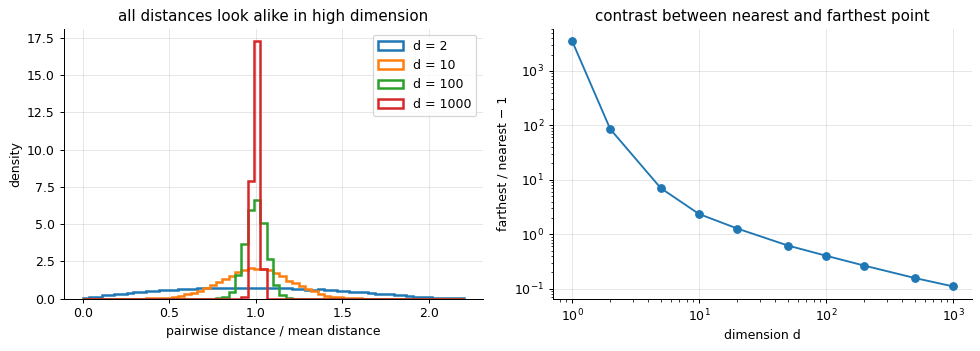

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for d, c in zip([2, 10, 100, 1000], ["tab:blue", "tab:orange", "tab:green", "tab:red"]):
    pd_ = pdist(rng.random((300, d)))
    axes[0].hist(pd_ / pd_.mean(), bins=60, range=(0, 2.2), density=True, histtype="step", lw=2, color=c, label=f"d = {d}")
axes[0].set_xlabel("pairwise distance / mean distance"); axes[0].set_ylabel("density"); axes[0].legend()
axes[0].set_title("all distances look alike in high dimension")
axes[1].loglog(dims, [ratio[d] - 1 for d in dims], "o-")
axes[1].set_xlabel("dimension d"); axes[1].set_ylabel("farthest / nearest − 1")
axes[1].set_title("contrast between nearest and farthest point")
plt.tight_layout(); plt.show()

**What just happened?** With 500 random points the farthest one is 86.5 times farther than the nearest one in 2-D, 3.36 times in 10-D, and only 1.11 times in 1000-D. The histogram of pairwise distances turns into a narrow spike around its mean: the measured relative spread of the squared distance is 0.371, 0.117 and 0.038 for $d$ = 10, 100, 1000, exactly the $1.183/\sqrt d$ of the proof.

**Things to notice.**
- Volume behaves just as oddly. The unit ball fills 79% of the cube $[-1,1]^2$, but only 0.25% of the cube in 10-D and $2.5 \cdot 10^{-8}$ in 20-D: almost all the volume sits in the corners, far from the centre. A fixed number of samples covers a vanishing fraction of the space.
- This is the **curse of dimensionality**: methods that rely on distances or on "local" neighbourhoods need exponentially many samples in $d$.
- Real data are not uniform in a cube. 64-pixel digits or 4,096-pixel faces have strongly correlated coordinates, so their *intrinsic* dimension is far below $d$. Every method in this lab exploits that.

## 2. PCA from scratch

### 2a. Two views of the same problem

Centre the data, so that $\bar{\mathbf{x}} = \mathbf{0}$. Choose a unit vector $\mathbf{w}$ ($\lVert\mathbf{w}\rVert = 1$) and project every point on the line it spans: the coordinate is $z_i = \mathbf{w}^\top\mathbf{x}_i$ and the reconstruction is $z_i\mathbf{w}$. Two natural goals:

- **maximum variance**: keep as much spread as possible, $\frac{1}{n-1}\sum_i z_i^2 = \mathbf{w}^\top\mathbf{S}\mathbf{w}$;
- **minimum reconstruction error**: lose as little as possible, $\frac{1}{n-1}\sum_i\lVert\mathbf{x}_i - z_i\mathbf{w}\rVert^2$.

**They are the same goal.** The residual $\mathbf{x}_i - z_i\mathbf{w}$ is orthogonal to $\mathbf{w}$, so by Pythagoras $\lVert\mathbf{x}_i\rVert^2 = z_i^2 + \lVert\mathbf{x}_i - z_i\mathbf{w}\rVert^2$. Sum over $i$ and divide by $n-1$:

$$
\underbrace{\operatorname{tr}\mathbf{S}}_{\text{total variance, fixed}} = \underbrace{\mathbf{w}^\top\mathbf{S}\mathbf{w}}_{\text{variance captured}} + \underbrace{\tfrac{1}{n-1}\textstyle\sum_i\lVert\mathbf{x}_i - z_i\mathbf{w}\rVert^2}_{\text{reconstruction error}} .
$$

The total does not depend on $\mathbf{w}$, so whatever increases the first term decreases the second by the same amount.

**Solving it with a Lagrange multiplier.** Maximise $\mathbf{w}^\top\mathbf{S}\mathbf{w}$ subject to $\mathbf{w}^\top\mathbf{w} = 1$. With $\mathcal{L}(\mathbf{w}, \lambda) = \mathbf{w}^\top\mathbf{S}\mathbf{w} - \lambda(\mathbf{w}^\top\mathbf{w} - 1)$,

$$
\nabla_{\mathbf{w}}\mathcal{L} = 2\mathbf{S}\mathbf{w} - 2\lambda\mathbf{w} = \mathbf{0} \quad\Longrightarrow\quad \mathbf{S}\mathbf{w} = \lambda\mathbf{w} .
$$

The stationary points are the eigenvectors of $\mathbf{S}$, and at an eigenvector the objective is $\mathbf{w}^\top\mathbf{S}\mathbf{w} = \lambda\,\mathbf{w}^\top\mathbf{w} = \lambda$. So the best direction is the eigenvector with the **largest eigenvalue**, $\mathbf{v}_1$, and the variance it captures is $\lambda_1$. The second direction maximises the same objective among the unit vectors orthogonal to $\mathbf{v}_1$, which gives $\mathbf{v}_2$, and so on. With $k$ directions, the captured variance is $\lambda_1 + \dots + \lambda_k$ and the reconstruction error is the rest, $\lambda_{k+1} + \dots + \lambda_d$.

We check all of it on a 2-D cloud by scanning every direction $\mathbf{w} = (\cos\theta, \sin\theta)$.

In [4]:
X2 = rng.multivariate_normal([2.0, 1.0], [[3.0, 1.6], [1.6, 1.4]], size=200)
X2c = X2 - X2.mean(0)
S2 = X2c.T @ X2c / (len(X2) - 1)
lam2, V2 = np.linalg.eigh(S2)                              # ascending order
lam2, V2 = lam2[::-1], V2[:, ::-1]

thetas = np.deg2rad(np.arange(0, 180, 0.25))
W = np.stack([np.cos(thetas), np.sin(thetas)], 1)          # one unit vector per row
Zt = X2c @ W.T                                             # (n, angles): coordinates on each line
var_t = (Zt ** 2).sum(0) / (len(X2) - 1)
err_t = np.array([((X2c - np.outer(Zt[:, a], W[a])) ** 2).sum() for a in range(len(thetas))]) / (len(X2) - 1)

pc1_angle = np.rad2deg(np.arctan2(V2[1, 0], V2[0, 0])) % 180
print(f"total variance tr(S) = {np.trace(S2):.4f};  max |captured + error - total| = {np.abs(var_t + err_t - np.trace(S2)).max():.1e}")
print(f"best angle for variance: {np.rad2deg(thetas[var_t.argmax()]):.2f} deg;  best for error: {np.rad2deg(thetas[err_t.argmin()]):.2f} deg;  "
      f"angle of v1: {pc1_angle:.2f} deg")
print(f"max captured variance {var_t.max():.4f}  vs  lambda_1 = {lam2[0]:.4f};   min error {err_t.min():.4f}  vs  lambda_2 = {lam2[1]:.4f}")
assert np.allclose(var_t + err_t, np.trace(S2))
assert var_t.argmax() == err_t.argmin()
assert abs(var_t.max() - lam2[0]) < 1e-4 and abs(err_t.min() - lam2[1]) < 1e-4

total variance tr(S) = 4.6915;  max |captured + error - total| = 4.4e-15
best angle for variance: 34.75 deg;  best for error: 34.75 deg;  angle of v1: 34.63 deg
max captured variance 4.3120  vs  lambda_1 = 4.3120;   min error 0.3795  vs  lambda_2 = 0.3795


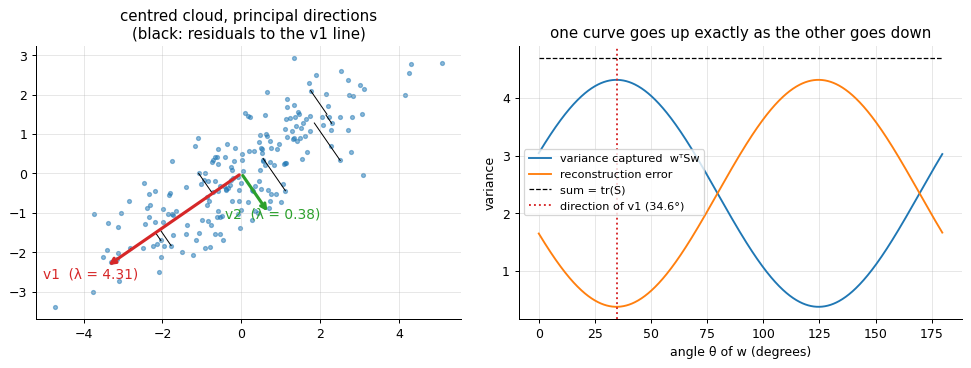

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.scatter(X2c[:, 0], X2c[:, 1], s=10, alpha=0.5)
for j, c in [(0, "tab:red"), (1, "tab:green")]:
    v = V2[:, j] * 2 * np.sqrt(lam2[j])
    ax.annotate("", xy=v, xytext=(0, 0), arrowprops=dict(arrowstyle="->", lw=2.5, color=c))
    ax.text(*(v * 1.12), f"v{j+1}  (λ = {lam2[j]:.2f})", color=c, ha="center", fontsize=11)
for i in range(0, 200, 25):                                # a few residuals to the PC1 line
    p = (X2c[i] @ V2[:, 0]) * V2[:, 0]
    ax.plot([X2c[i, 0], p[0]], [X2c[i, 1], p[1]], "k-", lw=0.8)
ax.set_aspect("equal"); ax.set_title("centred cloud, principal directions\n(black: residuals to the v1 line)")
ax = axes[1]
deg = np.rad2deg(thetas)
ax.plot(deg, var_t, label="variance captured  wᵀSw")
ax.plot(deg, err_t, label="reconstruction error")
ax.plot(deg, var_t + err_t, "k--", lw=1, label="sum = tr(S)")
ax.axvline(pc1_angle, color="tab:red", ls=":", label=f"direction of v1 ({pc1_angle:.1f}°)")
ax.set_xlabel("angle θ of w (degrees)"); ax.set_ylabel("variance"); ax.legend(fontsize=9)
ax.set_title("one curve goes up exactly as the other goes down")
plt.tight_layout(); plt.show()

**What just happened?** Over all 720 directions, captured variance plus reconstruction error equals $\operatorname{tr}\mathbf{S}$ = 4.69 to rounding ($10^{-15}$). The best direction for both goals is the same grid angle, 34.75°, the grid point (step 0.25°) closest to the direction of the top eigenvector, 34.63°. The largest captured variance equals $\lambda_1$ = 4.312 and the smallest error equals $\lambda_2$ = 0.380, as the Lagrange argument predicts.

**Interpretation.** PCA is at the same time the best linear *summary* (most variance kept) and the best linear *compression* (least squared error when we go back). That is also why a linear autoencoder trained with the squared error learns the PCA subspace (Extra 3 · Autoencoders). The two views differ in what they suggest next: "variance" leads to the eigenvectors of $\mathbf{S}$, "reconstruction" leads to low-rank approximation of $\mathbf{X}_c$, which is the SVD.

### 2b. Two algorithms: eigenvectors of $\mathbf{S}$, or the SVD of $\mathbf{X}_c$

**Eigen-decomposition.** Form $\mathbf{S} = \frac{1}{n-1}\mathbf{X}_c^\top\mathbf{X}_c$ ($d \times d$), diagonalise $\mathbf{S} = \mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^\top$, sort by decreasing eigenvalue, keep $\mathbf{V}_k$, and compute the scores $\mathbf{Z} = \mathbf{X}_c\mathbf{V}_k$. Cost: $O(nd^2)$ for $\mathbf{S}$ plus $O(d^3)$.

**SVD.** Every matrix factors as $\mathbf{X}_c = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^\top$, with orthonormal columns in $\mathbf{U}$ ($n \times r$) and $\mathbf{V}$ ($d \times r$) and singular values $\sigma_1 \ge \dots \ge \sigma_r \ge 0$ on the diagonal of $\boldsymbol{\Sigma}$. Then

$$
\mathbf{X}_c^\top\mathbf{X}_c = \mathbf{V}\boldsymbol{\Sigma}\mathbf{U}^\top\mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^\top = \mathbf{V}\boldsymbol{\Sigma}^2\mathbf{V}^\top
\quad\Longrightarrow\quad \lambda_j = \frac{\sigma_j^2}{n-1}, \qquad \mathbf{Z} = \mathbf{X}_c\mathbf{V}_k = \mathbf{U}_k\boldsymbol{\Sigma}_k .
$$

The right singular vectors are the principal directions, and the scores come for free. The Eckart–Young theorem says that $\mathbf{U}_k\boldsymbol{\Sigma}_k\mathbf{V}_k^\top$ is the best rank-$k$ approximation of $\mathbf{X}_c$ in squared error: the "reconstruction" view again. scikit-learn's `PCA` uses the SVD (a randomized one for large data), never $\mathbf{S}$. **Signs are arbitrary**: if $\mathbf{v}$ is an eigenvector, so is $-\mathbf{v}$, so two correct implementations may differ by the sign of whole columns. Our `flip` helper aligns them before comparing.

The data: scikit-learn's **digits**, 1,797 images of $8 \times 8$ pixels with values 0 to 16, so $d = 64$.

In [6]:
digits = load_digits()
Xd, yd = digits.data, digits.target
n_d = len(Xd)
print("digits:", Xd.shape, "pixel values", Xd.min(), "to", Xd.max())

def pca_eig(X, k):
    mu = X.mean(0); Xc = X - mu
    S = Xc.T @ Xc / (len(X) - 1)
    lam, V = np.linalg.eigh(S)                   # symmetric matrix: real eigenvalues, ascending
    order = np.argsort(lam)[::-1]
    lam, V = lam[order], V[:, order]
    return mu, lam, V[:, :k], Xc @ V[:, :k]

def pca_svd(X, k):
    mu = X.mean(0); Xc = X - mu
    U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
    return mu, s ** 2 / (len(X) - 1), Vt[:k].T, U[:, :k] * s[:k]

mu_e, lam_e, V_e, Z_e = pca_eig(Xd, 10)
mu_s, lam_s, V_s, Z_s = pca_svd(Xd, 10)
sk = PCA(n_components=10).fit(Xd)
V_sk, Z_sk = sk.components_.T, sk.transform(Xd)

print("eigenvalues (eig): ", lam_e[:5])
print("sigma^2/(n-1) (svd):", lam_s[:5])
print("sklearn explained_variance_:", sk.explained_variance_[:5])
print("max |V_eig - V_svd| after sign alignment:", np.abs(flip(V_e, V_s) - V_s).max())
print("max |Z_svd - Z_sklearn| after sign alignment:", np.abs(flip(Z_s, Z_sk) - Z_sk).max())
print("columns whose sign differs between eig and svd:", int((np.sign((V_e * V_s).sum(0)) < 0).sum()), "of 10")
assert np.allclose(lam_e[:10], lam_s[:10]) and np.allclose(lam_s[:10], sk.explained_variance_)
assert np.allclose(flip(V_e, V_s), V_s, atol=1e-8) and np.allclose(flip(V_s, V_sk), V_sk, atol=1e-8)
assert np.allclose(flip(Z_s, Z_sk), Z_sk, atol=1e-6)

digits: (1797, 64) pixel values 0.0 to 16.0
eigenvalues (eig):  [179.007 163.718 141.788 101.1    69.513]
sigma^2/(n-1) (svd): [179.007 163.718 141.788 101.1    69.513]
sklearn explained_variance_: [179.007 163.718 141.788 101.1    69.513]
max |V_eig - V_svd| after sign alignment: 5.322131624296844e-15
max |Z_svd - Z_sklearn| after sign alignment: 5.044853423896711e-13
columns whose sign differs between eig and svd: 6 of 10


The reconstruction error with $k$ components should be the sum of the discarded eigenvalues, $\frac{1}{n-1}\sum_i\lVert\mathbf{x}_i - \hat{\mathbf{x}}_i\rVert^2 = \sum_{j > k}\lambda_j$. And a numerical warning: forming $\mathbf{X}^\top\mathbf{X}$ **squares** the condition number, so small singular values can be lost in floating point. The classic example is the Läuchli matrix with $\varepsilon = 10^{-8}$: in $\mathbf{X}^\top\mathbf{X}$ the entry $1 + \varepsilon^2$ rounds to $1$.

In [7]:
mu_full, lam_full, V_full, _ = pca_svd(Xd, 64)
errs = []
for k in range(65):
    Xhat = (Xd - mu_full) @ V_full[:, :k] @ V_full[:, :k].T + mu_full
    errs.append(((Xd - Xhat) ** 2).sum() / (n_d - 1))
errs = np.array(errs)
tail = np.array([lam_full[k:].sum() for k in range(65)])
for k in [2, 10, 30]:
    print(f"k = {k:2d}: reconstruction error {errs[k]:8.3f}   sum of discarded eigenvalues {tail[k]:8.3f}")
assert np.allclose(errs, tail, atol=1e-8)

eps = 1e-8
L = np.array([[1.0, 1.0], [eps, 0.0], [0.0, eps]])
print("Läuchli matrix, singular values by SVD:     ", [f"{v:.3e}" for v in np.linalg.svd(L, compute_uv=False)])
print("square roots of the eigenvalues of L^T L:   ", [f"{v:.3e}" for v in np.sqrt(np.clip(np.linalg.eigvalsh(L.T @ L), 0, None))[::-1]])

k =  2: reconstruction error  859.423   sum of discarded eigenvalues  859.423
k = 10: reconstruction error  314.690   sum of discarded eigenvalues  314.690
k = 30: reconstruction error   49.185   sum of discarded eigenvalues   49.185
Läuchli matrix, singular values by SVD:      ['1.414e+00', '1.000e-08']
square roots of the eigenvalues of L^T L:    ['1.414e+00', '0.000e+00']


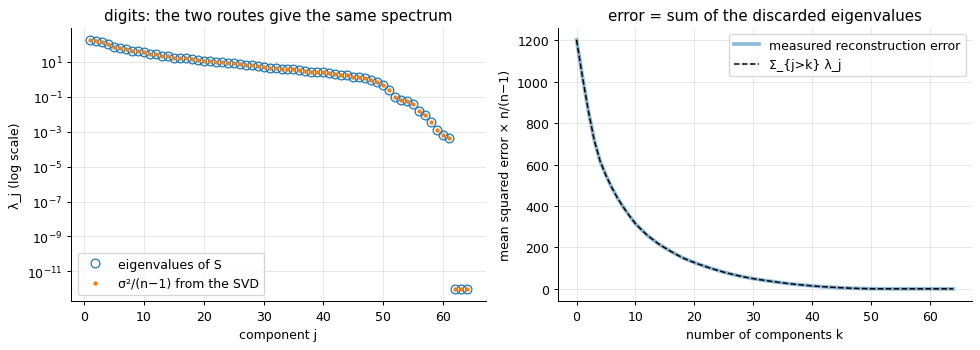

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
j = np.arange(1, 65)
lam_eig_all = pca_eig(Xd, 64)[1]
axes[0].semilogy(j, np.clip(lam_eig_all, 1e-12, None), "o", ms=7, mfc="none", label="eigenvalues of S")
axes[0].semilogy(j, np.clip(lam_full, 1e-12, None), ".", ms=5, label="σ²/(n−1) from the SVD")
axes[0].set_xlabel("component j"); axes[0].set_ylabel("λ_j (log scale)"); axes[0].legend()
axes[0].set_title("digits: the two routes give the same spectrum")
axes[1].plot(range(65), errs, lw=3, alpha=0.5, label="measured reconstruction error")
axes[1].plot(range(65), tail, "k--", lw=1.2, label="Σ_{j>k} λ_j")
axes[1].set_xlabel("number of components k"); axes[1].set_ylabel("mean squared error × n/(n−1)"); axes[1].legend()
axes[1].set_title("error = sum of the discarded eigenvalues")
plt.tight_layout(); plt.show()

**What just happened?** On the 1,797 digits the two routes and scikit-learn agree: the same eigenvalues (the first is $\lambda_1$ = 179.0), the same directions up to sign (6 of the 10 columns came out with the opposite sign in the eigen route, which is why we align before comparing) and the same scores to $10^{-12}$. The reconstruction error equals the sum of the discarded eigenvalues for every $k$, for instance 314.7 with $k = 10$.

**Things to notice.**
- The last few eigenvalues are essentially zero (the plot clips them at $10^{-12}$): some border pixels are always 0, so the data live in fewer than 64 dimensions.
- The Läuchli matrix shows why libraries prefer the SVD: it finds the small singular value $10^{-8}$, while the eigenvalues of $\mathbf{X}^\top\mathbf{X}$ give $0$ for it. With real data the loss is milder, but the rule stands: never form $\mathbf{X}^\top\mathbf{X}$ if you can factor $\mathbf{X}$.
- When $n \ll d$ (400 faces of 4,096 pixels in section 4), the SVD of the $n \times d$ matrix is also much cheaper than diagonalising a $d \times d$ covariance.

## 3. Explained variance, choosing $k$, standardisation and whitening

The share of variance kept by component $j$ is the **explained variance ratio** $\lambda_j / \sum_l\lambda_l$. Plotted against $j$ it is the **scree plot**. Common ways to choose $k$:

1. the smallest $k$ whose cumulative ratio passes a threshold (90% or 95%);
2. the **elbow** of the scree plot, where the curve flattens;
3. for standardised data, **Kaiser's rule**: keep components with $\lambda_j > 1$, i.e. those that explain more than one original feature;
4. the best: treat $k$ as a hyper-parameter of the downstream task and choose it by cross-validation.

**Standardise or not?** PCA maximises variance, and variance depends on units. Measure one feature in millimetres instead of metres and its variance grows by $10^6$: it will own the first component. When features have different units, divide each by its standard deviation first (this is PCA on the **correlation** matrix). When they share a unit and the scale is meaningful (pixels, word counts), keep the raw scale.

The data: the **wine** dataset, 178 wines from 3 cultivars, 13 chemical measurements in very different units.

In [9]:
wine = load_wine()
Xw, yw = wine.data, wine.target
names_w = wine.feature_names
print("std of each feature:")
for nm, s in zip(names_w, Xw.std(0)):
    print(f"   {nm:30s} {s:9.2f}")

pca_raw = PCA().fit(Xw)
Xw_std = StandardScaler().fit_transform(Xw)
pca_std = PCA().fit(Xw_std)
cum_std = np.cumsum(pca_std.explained_variance_ratio_)
print(f"\nraw data:          PC1 explains {pca_raw.explained_variance_ratio_[0]:.2%};  its largest loading is "
      f"{names_w[np.abs(pca_raw.components_[0]).argmax()]} ({np.abs(pca_raw.components_[0]).max():.4f})")
print("standardised data: explained variance ratios", (100 * pca_std.explained_variance_ratio_[:5]).round(1), "%")
print("                   cumulative             ", (100 * cum_std[:8]).round(1), "%")
print(f"k for 90%: {np.searchsorted(cum_std, 0.90) + 1}   k for 95%: {np.searchsorted(cum_std, 0.95) + 1}   "
      f"Kaiser (lambda > 1): {(pca_std.explained_variance_ > 1).sum()}   eigenvalues {pca_std.explained_variance_[:4].round(3)}")

knn = KNeighborsClassifier(5)
acc_raw = cross_val_score(make_pipeline(PCA(2), knn), Xw, yw, cv=5).mean()
acc_std = cross_val_score(make_pipeline(StandardScaler(), PCA(2), knn), Xw, yw, cv=5).mean()
print(f"\n5-NN accuracy on 2 PCA scores (5-fold CV):  raw {acc_raw:.3f}   standardised {acc_std:.3f}")

std of each feature:
   alcohol                             0.81
   malic_acid                          1.11
   ash                                 0.27
   alcalinity_of_ash                   3.33
   magnesium                          14.24
   total_phenols                       0.62
   flavanoids                          1.00
   nonflavanoid_phenols                0.12
   proanthocyanins                     0.57
   color_intensity                     2.31
   hue                                 0.23
   od280/od315_of_diluted_wines        0.71
   proline                           314.02

raw data:          PC1 explains 99.81%;  its largest loading is proline (0.9998)
standardised data: explained variance ratios [36.2 19.2 11.1  7.1  6.6] %
                   cumulative              [36.2 55.4 66.5 73.6 80.2 85.1 89.3 92. ] %
k for 90%: 8   k for 95%: 10   Kaiser (lambda > 1): 3   eigenvalues [4.732 2.511 1.454 0.924]

5-NN accuracy on 2 PCA scores (5-fold CV):  raw 0.691   standardised 

**Whitening.** Dividing each score by its standard deviation, $\mathbf{Z}_w = \mathbf{Z}\boldsymbol{\Lambda}_k^{-1/2}$, gives uncorrelated coordinates with unit variance: $\frac{1}{n-1}\mathbf{Z}_w^\top\mathbf{Z}_w = \boldsymbol{\Lambda}_k^{-1/2}\mathbf{V}_k^\top\mathbf{S}\mathbf{V}_k\boldsymbol{\Lambda}_k^{-1/2} = \boldsymbol{\Lambda}_k^{-1/2}\boldsymbol{\Lambda}_k\boldsymbol{\Lambda}_k^{-1/2} = \mathbf{I}$. It is a common preprocessing step (ICA, some clustering, older image pipelines). Rotating back, $\mathbf{Z}_w\mathbf{V}_k^\top$, gives **ZCA** whitening, which stays close to the original features. The catch: low-variance directions, often noise, are blown up to the same size as the signal.

In [10]:
Zw_raw = Xw_std @ pca_std.components_[:3].T                     # data already centred by StandardScaler
Zw = Zw_raw / np.sqrt(pca_std.explained_variance_[:3])
cov_w = Zw.T @ Zw / (len(Zw) - 1)
print("covariance of the whitened scores:\n", cov_w)
sk_w = PCA(3, whiten=True).fit_transform(Xw_std)
print("max |ours - sklearn PCA(whiten=True)| after sign alignment:", np.abs(flip(Zw, sk_w) - sk_w).max())
assert np.allclose(cov_w, np.eye(3)) and np.allclose(flip(Zw, sk_w), sk_w)

covariance of the whitened scores:
 [[ 1. -0. -0.]
 [-0.  1.  0.]
 [-0.  0.  1.]]
max |ours - sklearn PCA(whiten=True)| after sign alignment: 3.552713678800501e-15


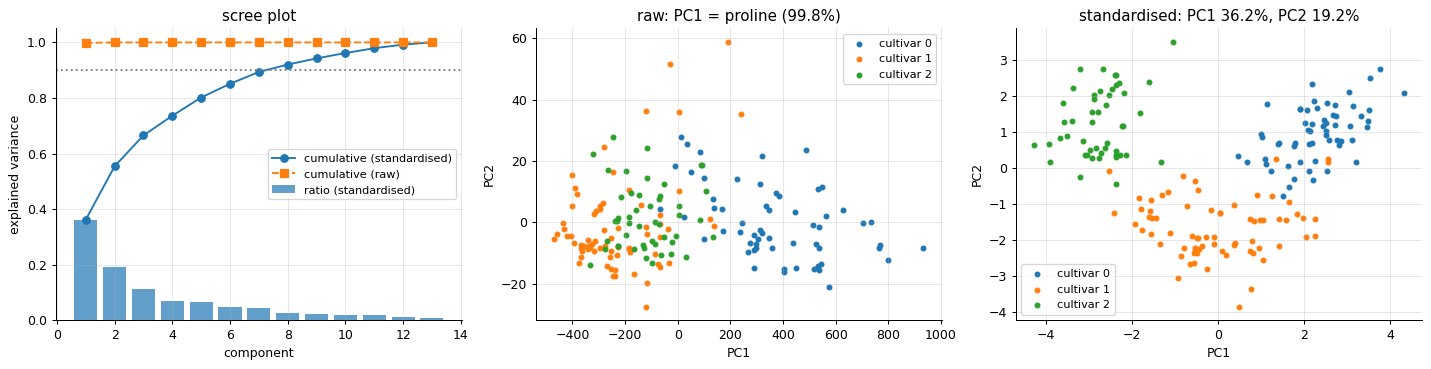

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
j = np.arange(1, 14)
axes[0].bar(j, pca_std.explained_variance_ratio_, color="tab:blue", alpha=0.7, label="ratio (standardised)")
axes[0].plot(j, cum_std, "o-", color="tab:blue", label="cumulative (standardised)")
axes[0].plot(j, np.cumsum(pca_raw.explained_variance_ratio_), "s--", color="tab:orange", label="cumulative (raw)")
axes[0].axhline(0.9, color="gray", ls=":"); axes[0].set_xlabel("component"); axes[0].set_ylabel("explained variance")
axes[0].legend(fontsize=9); axes[0].set_title("scree plot")
for ax, P, title in [(axes[1], pca_raw.transform(Xw)[:, :2], f"raw: PC1 = proline ({pca_raw.explained_variance_ratio_[0]:.1%})"),
                     (axes[2], pca_std.transform(Xw_std)[:, :2], "standardised: PC1 36.2%, PC2 19.2%")]:
    for c in range(3):
        ax.scatter(P[yw == c, 0], P[yw == c, 1], s=14, label=f"cultivar {c}")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title(title); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**What just happened?** The feature `proline` has a standard deviation of 314.0, against 0.23 for `hue`. On the raw data the first component explains 99.81% of the variance and is almost exactly the proline axis (loading 0.9998): PCA has found the feature with the largest unit, not structure. After standardisation the variance is spread out (36.2%, 19.2%, 11.1%, …), the three cultivars separate in the first two components, and a 5-NN classifier on those two scores goes from 0.691 (raw) to 0.966 (standardised).

**Choosing $k$ on the standardised wine data**: 90% needs $k$ = 8, 95% needs $k$ = 10, Kaiser's rule keeps 3 components (eigenvalues 4.73, 2.51, 1.45, then 0.92). The rules disagree, which is normal: they answer different questions. For a 2-D plot $k = 2$; for a model, cross-validate. Whitening gives exactly the identity covariance and matches `PCA(whiten=True)`.

## 4. PCA on images: eigendigits, eigenfaces, denoising

An image with $d$ pixels is a point in $\mathbb{R}^d$, and a principal direction $\mathbf{v}_j$ is itself an image. PCA writes every image as the mean image plus a weighted sum of these basis images,

$$
\hat{\mathbf{x}} = \bar{\mathbf{x}} + z_1\mathbf{v}_1 + z_2\mathbf{v}_2 + \dots + z_k\mathbf{v}_k ,
$$

with the weights $z_j = \mathbf{v}_j^\top(\mathbf{x} - \bar{\mathbf{x}})$. On faces the $\mathbf{v}_j$ are the famous **eigenfaces** (Turk and Pentland, 1991). Storing $k$ numbers per image instead of $d$ is compression; projecting a noisy image on the top-$k$ subspace is denoising: the clean digits live near that subspace, while white noise spreads equally over all $d$ directions, so the projection keeps only a fraction $k/d$ of the noise energy.

digits: PC1 14.9%, first 2 28.5%, first 10 73.8%, first 20 89.4%
        k for 90%: 21   k for 95%: 29  (of 64)


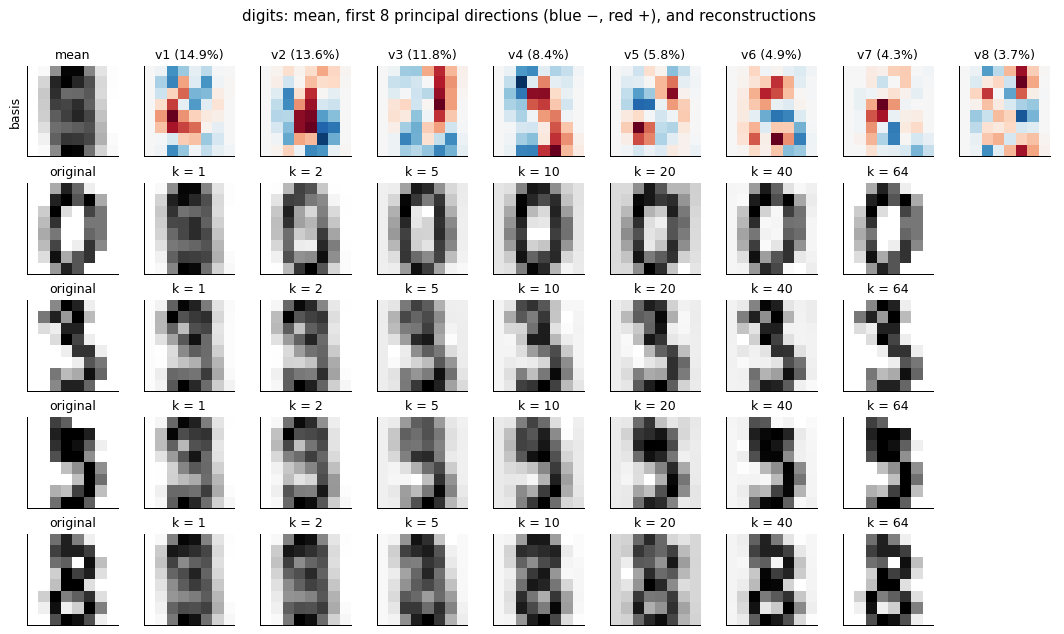

In [12]:
pca_d = PCA().fit(Xd)
cum_d = np.cumsum(pca_d.explained_variance_ratio_)
print(f"digits: PC1 {pca_d.explained_variance_ratio_[0]:.1%}, first 2 {cum_d[1]:.1%}, first 10 {cum_d[9]:.1%}, first 20 {cum_d[19]:.1%}")
print(f"        k for 90%: {np.searchsorted(cum_d, 0.90) + 1}   k for 95%: {np.searchsorted(cum_d, 0.95) + 1}  (of 64)")

ks_d = [1, 2, 5, 10, 20, 40, 64]
pick = [int(np.where(yd == c)[0][0]) for c in [0, 3, 5, 8]]     # the first 0, 3, 5 and 8
fig, axes = plt.subplots(5, 9, figsize=(12, 7))
show_img(axes[0, 0], pca_d.mean_.reshape(8, 8), "mean")
for j in range(8):
    v = pca_d.components_[j].reshape(8, 8)
    axes[0, j + 1].imshow(v, cmap="RdBu_r", vmin=-np.abs(v).max(), vmax=np.abs(v).max())
    axes[0, j + 1].set_xticks([]); axes[0, j + 1].set_yticks([]); axes[0, j + 1].grid(False)
    axes[0, j + 1].set_title(f"v{j+1} ({pca_d.explained_variance_ratio_[j]:.1%})", fontsize=10)
for r, i in enumerate(pick, start=1):
    show_img(axes[r, 0], Xd[i].reshape(8, 8), "original")
    z = pca_d.transform(Xd[i:i + 1])[0]
    for c, k in enumerate(ks_d):
        rec = pca_d.mean_ + z[:k] @ pca_d.components_[:k]
        show_img(axes[r, c + 1], rec.reshape(8, 8), f"k = {k}")
    axes[r, 8].axis("off")
axes[0, 0].set_ylabel("basis"); plt.suptitle("digits: mean, first 8 principal directions (blue −, red +), and reconstructions", y=1.0)
plt.tight_layout(); plt.show()

faces: (400, 4096) | components: 400 (at most n - 1 = 399 carry variance)
cumulative explained variance: {1: '23.8%', 5: '54.4%', 10: '65.6%', 20: '76.3%', 50: '87.4%', 100: '93.5%', 200: '97.9%'}
k for 90%: 66   k for 95%: 123  (of 4096 pixels)


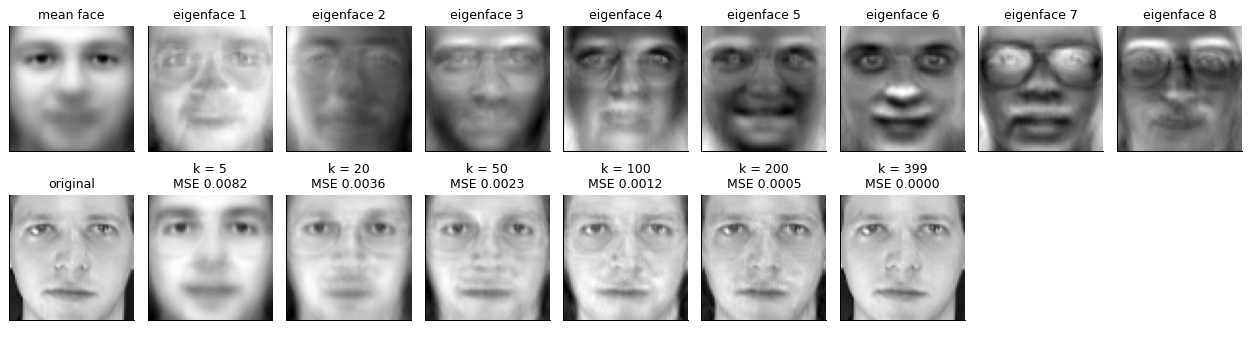

In [13]:
faces = fetch_olivetti_faces(data_home="data/sklearn", shuffle=False)
Xf = faces.data                                             # 400 x 4096, grey levels in [0, 1]
pca_f = PCA().fit(Xf)
cum_f = np.cumsum(pca_f.explained_variance_ratio_)
print("faces:", Xf.shape, "| components:", pca_f.n_components_, "(at most n - 1 = 399 carry variance)")
print("cumulative explained variance:", {k: f"{cum_f[k - 1]:.1%}" for k in [1, 5, 10, 20, 50, 100, 200]})
print(f"k for 90%: {np.searchsorted(cum_f, 0.90) + 1}   k for 95%: {np.searchsorted(cum_f, 0.95) + 1}  (of 4096 pixels)")

ks_f = [5, 20, 50, 100, 200, 399]
i_face = 0
z_f = pca_f.transform(Xf[i_face:i_face + 1])[0]
fig, axes = plt.subplots(2, 9, figsize=(14, 3.9))
show_img(axes[0, 0], pca_f.mean_.reshape(64, 64), "mean face", cmap="gray")
for j in range(8):
    show_img(axes[0, j + 1], pca_f.components_[j].reshape(64, 64), f"eigenface {j+1}", cmap="gray")
show_img(axes[1, 0], Xf[i_face].reshape(64, 64), "original", cmap="gray")
for c, k in enumerate(ks_f):
    rec = pca_f.mean_ + z_f[:k] @ pca_f.components_[:k]
    mse = np.mean((rec - Xf[i_face]) ** 2)
    show_img(axes[1, c + 1], rec.reshape(64, 64), f"k = {k}\nMSE {mse:.4f}", cmap="gray")
for c in [7, 8]: axes[1, c].axis("off")
plt.tight_layout(); plt.show()

MSE of the noisy test digits vs the clean ones: 16.04  (= sigma^2 = 16)
after projection on k components: k = 5 -> 10.15,  k = 18 (best) -> 6.91,  k = 64 -> 16.04
noise energy kept by the projection, theory sigma^2 k/d at k = 18: 4.50


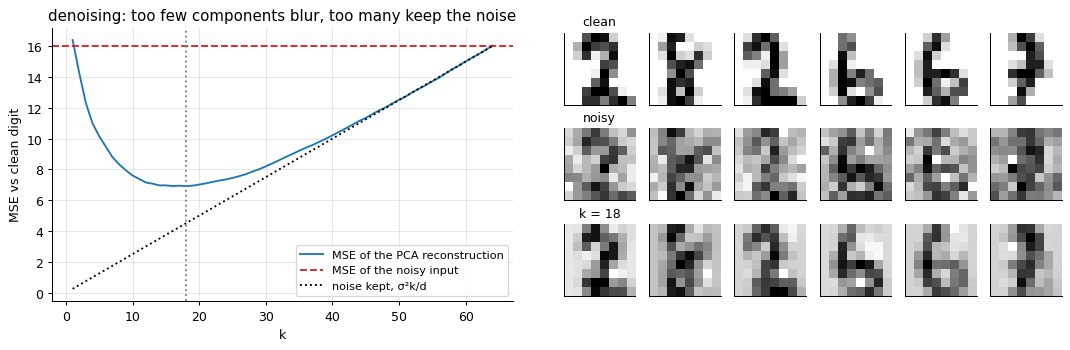

In [14]:
Xtr, Xte = train_test_split(Xd, test_size=0.3, random_state=0)
sigma = 4.0                                                 # noise std, on pixels that range from 0 to 16
Xte_noisy = Xte + sigma * rng.standard_normal(Xte.shape)
pca_dn = PCA().fit(Xtr)                                     # fitted on clean training digits
Zte = pca_dn.transform(Xte_noisy)
mse_k = np.array([np.mean((pca_dn.mean_ + Zte[:, :k] @ pca_dn.components_[:k] - Xte) ** 2) for k in range(1, 65)])
k_best = int(mse_k.argmin()) + 1
print(f"MSE of the noisy test digits vs the clean ones: {np.mean((Xte_noisy - Xte) ** 2):.2f}  (= sigma^2 = {sigma**2:.0f})")
print(f"after projection on k components: k = 5 -> {mse_k[4]:.2f},  k = {k_best} (best) -> {mse_k[k_best - 1]:.2f},  k = 64 -> {mse_k[63]:.2f}")
print(f"noise energy kept by the projection, theory sigma^2 k/d at k = {k_best}: {sigma**2 * k_best / 64:.2f}")

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(range(1, 65), mse_k, label="MSE of the PCA reconstruction")
ax.axhline(sigma ** 2, color="tab:red", ls="--", label="MSE of the noisy input")
ax.plot(range(1, 65), sigma ** 2 * np.arange(1, 65) / 64, "k:", label="noise kept, σ²k/d")
ax.axvline(k_best, color="gray", ls=":"); ax.set_xlabel("k"); ax.set_ylabel("MSE vs clean digit"); ax.legend(fontsize=9)
ax.set_title("denoising: too few components blur, too many keep the noise")
for r, (row, lab) in enumerate([(Xte, "clean"), (Xte_noisy, "noisy"), (pca_dn.mean_ + Zte[:, :k_best] @ pca_dn.components_[:k_best], f"k = {k_best}")]):
    for c in range(6):
        a = fig.add_subplot(3, 12, 12 * r + 7 + c)
        show_img(a, row[c].reshape(8, 8)); a.set_title(lab if c == 0 else "", fontsize=10)
plt.tight_layout(); plt.show()

**What just happened?**
- **Digits.** PC1 alone explains 14.9% of the variance, 10 components 73.8%, and 90% needs 21 of the 64 dimensions (95% needs 29). Each direction adds ink in its red pixels and removes it in its blue ones; the first ones move large strokes, later ones fine detail. With $k = 10$ most digits are already recognisable.
- **Faces.** 400 photos of 4,096 pixels have at most 399 informative directions (centring removes one). 50 eigenfaces keep 87.4% of the variance; 90% needs $k$ = 66. The first eigenfaces encode lighting (from the left, from the right) and the overall shape; eigenfaces 7 and 8 contain glasses, because several of the 40 people wear them. The reconstruction error of the face shown falls from 0.0082 ($k = 5$) to 0.0023 ($k = 50$) and 0 with all 399 components.
- **Denoising.** Noise of standard deviation 4 gives an MSE of 16.0. Projecting on the best $k$ = 18 components brings it down to 6.91. With few components the reconstruction is biased (it cannot draw the digit); with many it keeps the noise, $\sigma^2k/d$ (dotted line), and at $k = 64$ it returns the noisy input unchanged (16.04).

**Interpretation.** PCA is a change of basis to directions ordered by importance. Keeping the top $k$ is the optimal linear compression for squared error, and the same truncation removes the energy of the noise in the discarded directions.

## 5. Random projections and the Johnson–Lindenstrauss lemma

PCA must look at the data to find its directions. A **random projection** does not: multiply by a random matrix $\mathbf{R} \in \mathbb{R}^{d \times k}$ with entries drawn from $\mathcal{N}(0, 1/k)$. Surprisingly, distances survive.

**Johnson–Lindenstrauss lemma (1984).** For any $n$ points in $\mathbb{R}^d$ and any $0 < \varepsilon < 1$, if

$$
k \;\ge\; \frac{4\ln n}{\varepsilon^2/2 - \varepsilon^3/3},
$$

there is a linear map to $\mathbb{R}^k$ (a random $\mathbf{R}$ works with high probability) such that for **every** pair, $(1 - \varepsilon)\lVert\mathbf{u} - \mathbf{v}\rVert^2 \le \lVert\mathbf{R}^\top\mathbf{u} - \mathbf{R}^\top\mathbf{v}\rVert^2 \le (1 + \varepsilon)\lVert\mathbf{u} - \mathbf{v}\rVert^2$. The bound does not depend on $d$.

**Why (sketch).** Fix one difference vector $\mathbf{x} = \mathbf{u} - \mathbf{v}$. Each coordinate of $\mathbf{R}^\top\mathbf{x}$ is a sum of Gaussians, $\mathcal{N}(0, \lVert\mathbf{x}\rVert^2/k)$, and the $k$ coordinates are independent. So $\lVert\mathbf{R}^\top\mathbf{x}\rVert^2/\lVert\mathbf{x}\rVert^2 \sim \chi^2_k/k$: mean 1, standard deviation $\sqrt{2/k}$, whatever $d$. A Chernoff bound gives $P(|\text{ratio} - 1| > \varepsilon) \le 2e^{-k(\varepsilon^2/2 - \varepsilon^3/3)/2}$, and a union bound over the $n(n-1)/2$ pairs gives the $\ln n$.

We check it on the 400 faces ($d = 4096$, 79,800 pairs).

In [15]:
d0 = pdist(Xf, "sqeuclidean")                               # all 79,800 squared distances
eps_jl = 0.2
k_jl = int(np.ceil(4 * np.log(len(Xf)) / (eps_jl ** 2 / 2 - eps_jl ** 3 / 3)))
print(f"JL bound for n = {len(Xf)}, eps = {eps_jl}: k >= {k_jl}   (sklearn's johnson_lindenstrauss_min_dim rounds down: {johnson_lindenstrauss_min_dim(len(Xf), eps=eps_jl)})")
assert abs(k_jl - johnson_lindenstrauss_min_dim(len(Xf), eps=eps_jl)) <= 1

ks_rp = [20, 50, 100, 200, 500, 1000, k_jl]
rp = {}
for k in ks_rp:
    R = rng.standard_normal((Xf.shape[1], k)) / np.sqrt(k)
    rp[k] = pdist(Xf @ R, "sqeuclidean") / d0               # distortion ratio of every pair
    print(f"k = {k:5d}: ratio mean {rp[k].mean():.3f}  std {rp[k].std():.4f} (theory sqrt(2/k) = {np.sqrt(2 / k):.4f})   "
          f"max |ratio - 1| = {np.abs(rp[k] - 1).max():.3f}")
assert np.abs(rp[k_jl] - 1).max() < eps_jl

r_sk = pdist(GaussianRandomProjection(n_components=200, random_state=0).fit_transform(Xf), "sqeuclidean") / d0
r_pca = pdist(PCA(50, svd_solver="full").fit_transform(Xf), "sqeuclidean") / d0
print(f"sklearn GaussianRandomProjection, k = 200: std {r_sk.std():.4f}   |  PCA with k = 50: ratio from {r_pca.min():.3f} to {r_pca.max():.3f} "
      f"(PCA can only shrink distances)")

JL bound for n = 400, eps = 0.2: k >= 1383   (sklearn's johnson_lindenstrauss_min_dim rounds down: 1382)
k =    20: ratio mean 1.022  std 0.3230 (theory sqrt(2/k) = 0.3162)   max |ratio - 1| = 1.970
k =    50: ratio mean 0.949  std 0.1744 (theory sqrt(2/k) = 0.2000)   max |ratio - 1| = 0.872
k =   100: ratio mean 1.100  std 0.1455 (theory sqrt(2/k) = 0.1414)   max |ratio - 1| = 0.752
k =   200: ratio mean 0.951  std 0.0936 (theory sqrt(2/k) = 0.1000)   max |ratio - 1| = 0.460
k =   500: ratio mean 0.967  std 0.0598 (theory sqrt(2/k) = 0.0632)   max |ratio - 1| = 0.264
k =  1000: ratio mean 1.021  std 0.0442 (theory sqrt(2/k) = 0.0447)   max |ratio - 1| = 0.208


k =  1383: ratio mean 0.997  std 0.0379 (theory sqrt(2/k) = 0.0380)   max |ratio - 1| = 0.168
sklearn GaussianRandomProjection, k = 200: std 0.1206   |  PCA with k = 50: ratio from 0.130 to 0.977 (PCA can only shrink distances)


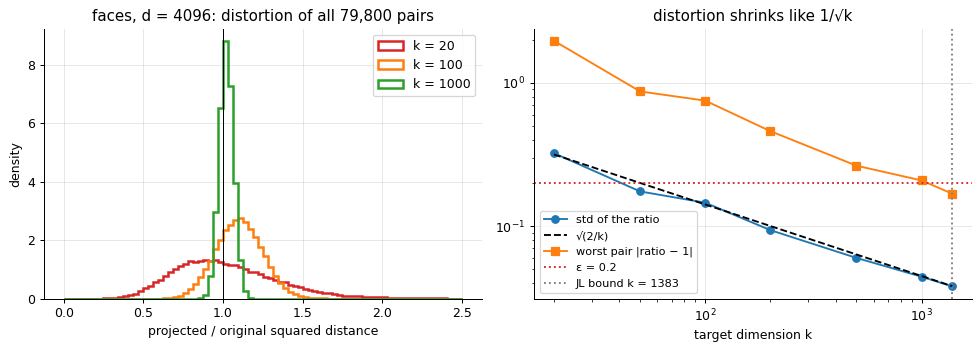

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for k, c in [(20, "tab:red"), (100, "tab:orange"), (1000, "tab:green")]:
    axes[0].hist(rp[k], bins=80, range=(0, 2.5), density=True, histtype="step", lw=2, color=c, label=f"k = {k}")
axes[0].axvline(1, color="k", lw=0.8); axes[0].set_xlabel("projected / original squared distance"); axes[0].set_ylabel("density")
axes[0].legend(); axes[0].set_title("faces, d = 4096: distortion of all 79,800 pairs")
kk = np.array(ks_rp)
axes[1].loglog(kk, [rp[k].std() for k in ks_rp], "o-", label="std of the ratio")
axes[1].loglog(kk, np.sqrt(2 / kk), "k--", label="√(2/k)")
axes[1].loglog(kk, [np.abs(rp[k] - 1).max() for k in ks_rp], "s-", label="worst pair |ratio − 1|")
axes[1].axhline(eps_jl, color="tab:red", ls=":", label=f"ε = {eps_jl}"); axes[1].axvline(k_jl, color="gray", ls=":", label=f"JL bound k = {k_jl}")
axes[1].set_xlabel("target dimension k"); axes[1].legend(fontsize=9); axes[1].set_title("distortion shrinks like 1/√k")
plt.tight_layout(); plt.show()

**What just happened?** The JL bound for 400 points and $\varepsilon = 0.2$ is $k$ = 1,383, and with that $k$ the worst of the 79,800 pairs is distorted by 0.168, inside the promised 20%. The spread of the distortion follows $\sqrt{2/k}$ (0.146 measured at $k = 100$ against 0.141 in theory) and does not care that $d = 4096$.

**Things to notice.**
- The bound is pessimistic: it guarantees *every* pair, for *any* data. Typical pairs are much better: at $k = 200$ the standard deviation is already about 0.1.
- PCA with 50 components keeps the faces' distances better on average, but its ratios are all below 1 (from 0.130 to 0.977): projecting on a subspace can only shorten vectors. PCA needs the data and an SVD; a random projection is data-independent, one matrix multiply, and works on streams. Sparse versions (entries $0, \pm 1$; Achlioptas 2003) are faster still.
- Random projections are used to speed up nearest-neighbour search (locality-sensitive hashing), to sketch huge matrices (randomized SVD, which scikit-learn's PCA uses for large data) and to compress features.

## 6. Supervised and non-negative cousins: LDA, LSA, NMF

### 6a. LDA: reduce while keeping the classes apart

PCA ignores labels: the direction of largest variance can mix the classes. **Linear discriminant analysis** (Fisher, 1936) looks for the direction that separates the class means relative to the spread inside each class. With class means $\boldsymbol{\mu}_c$, overall mean $\boldsymbol{\mu}$ and $n_c$ examples per class,

$$
\mathbf{S}_W = \sum_c\sum_{i \in c}(\mathbf{x}_i - \boldsymbol{\mu}_c)(\mathbf{x}_i - \boldsymbol{\mu}_c)^\top, \qquad
\mathbf{S}_B = \sum_c n_c(\boldsymbol{\mu}_c - \boldsymbol{\mu})(\boldsymbol{\mu}_c - \boldsymbol{\mu})^\top, \qquad
J(\mathbf{w}) = \frac{\mathbf{w}^\top\mathbf{S}_B\mathbf{w}}{\mathbf{w}^\top\mathbf{S}_W\mathbf{w}} .
$$

Setting the gradient of $J$ to zero gives the generalised eigenproblem $\mathbf{S}_B\mathbf{w} = \lambda\mathbf{S}_W\mathbf{w}$, and $J$ at an eigenvector equals its eigenvalue: same Lagrange story as PCA. $\mathbf{S}_B$ is a sum of $C$ rank-one matrices whose vectors sum to zero (weighted by $n_c$), so its rank is at most $C - 1$: **LDA gives at most $C - 1$ directions** (2 for wine, 9 for digits).

In [17]:
mu_all = Xw_std.mean(0)
Sw = np.zeros((13, 13)); Sb = np.zeros((13, 13))
for c in range(3):
    Xc_ = Xw_std[yw == c]; m = Xc_.mean(0)
    Sw += (Xc_ - m).T @ (Xc_ - m)
    Sb += len(Xc_) * np.outer(m - mu_all, m - mu_all)
ev_lda, W_lda = eigh(Sb, Sw)                                 # generalised symmetric eigenproblem
ev_lda, W_lda = ev_lda[::-1], W_lda[:, ::-1]
fisher = lambda w: (w @ Sb @ w) / (w @ Sw @ w)

lda_sk = LinearDiscriminantAnalysis(solver="eigen").fit(Xw_std, yw)
unit = lambda M: M / np.linalg.norm(M, axis=0)
diff = np.abs(flip(unit(W_lda[:, :2]), unit(lda_sk.scalings_[:, :2])) - unit(lda_sk.scalings_[:, :2])).max()
print("generalised eigenvalues:", ev_lda[:4].round(4), " -> only C - 1 = 2 are non-zero")
print(f"max difference with sklearn's LDA directions (unit length, sign aligned): {diff:.1e}")
print(f"Fisher ratio J(w):  LDA direction {fisher(W_lda[:, 0]):.3f} (= lambda_1)   PCA direction v1 {fisher(pca_std.components_[0]):.3f}")
assert diff < 1e-8 and abs(ev_lda[2]) < 1e-8 and np.isclose(fisher(W_lda[:, 0]), ev_lda[0])

# digits in 2-D: PCA vs LDA (fitted inside the cross-validation folds)
for name, red in [("PCA", PCA(2)), ("LDA", LinearDiscriminantAnalysis(n_components=2))]:
    acc = cross_val_score(make_pipeline(StandardScaler(), red, KNeighborsClassifier(5)), Xd, yd, cv=5).mean()
    print(f"digits, 5-NN on 2 {name} coordinates (5-fold CV): accuracy {acc:.3f}")
Zd_pca = PCA(2).fit_transform(StandardScaler().fit_transform(Xd))
Zd_lda = LinearDiscriminantAnalysis(n_components=2).fit_transform(StandardScaler().fit_transform(Xd), yd)

generalised eigenvalues: [9.082 4.128 0.    0.   ]  -> only C - 1 = 2 are non-zero
max difference with sklearn's LDA directions (unit length, sign aligned): 6.1e-16
Fisher ratio J(w):  LDA direction 9.082 (= lambda_1)   PCA direction v1 3.999
digits, 5-NN on 2 PCA coordinates (5-fold CV): accuracy 0.512
digits, 5-NN on 2 LDA coordinates (5-fold CV): accuracy 0.624


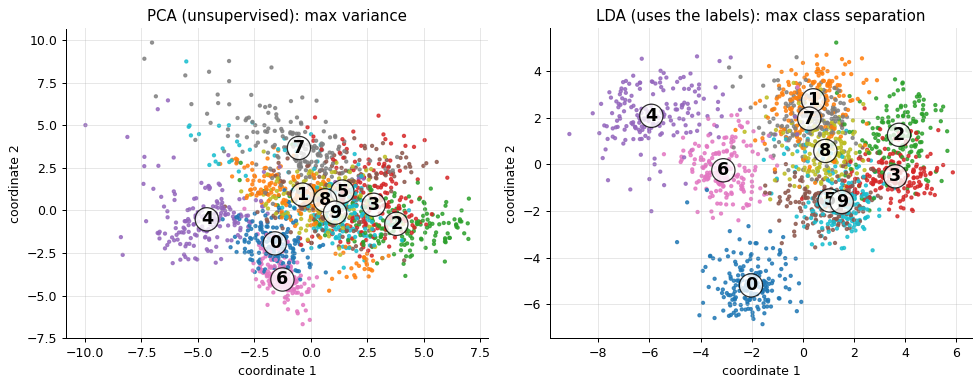

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, Z, title in [(axes[0], Zd_pca, "PCA (unsupervised): max variance"), (axes[1], Zd_lda, "LDA (uses the labels): max class separation")]:
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=yd, cmap="tab10", s=6, alpha=0.8)
    for c in range(10):
        m = np.median(Z[yd == c], axis=0)
        ax.text(m[0], m[1], str(c), fontsize=14, weight="bold", ha="center", va="center",
                bbox=dict(boxstyle="circle,pad=0.15", fc="white", alpha=0.8))
    ax.set_title(title); ax.set_xlabel("coordinate 1"); ax.set_ylabel("coordinate 2")
plt.tight_layout(); plt.show()

**What just happened?** Our LDA from scratch matches scikit-learn's directions to $10^{-15}$. Only 2 generalised eigenvalues are non-zero (9.08 and 4.13; the third is $10^{-15}$), as the rank argument says. Along the LDA direction the Fisher ratio is 9.08, against 4.00 along the first principal component. On the digits, two LDA coordinates give a 5-NN accuracy of 0.624 against 0.512 for two PCA coordinates: the LDA map pulls the ten digits apart, while PCA mixes several of them in the middle.

**Caveat.** LDA uses the labels, so it must be fitted inside each training fold (as the pipelines above do). Section 10 shows what happens when a supervised reduction sees the test labels.

### 6b. LSA: truncated SVD on sparse word counts

A collection of documents becomes a **document–term matrix**: one row per document, one column per word, counts in the cells. It is huge and sparse (most words are absent from most documents), so we do **not** centre it, which would fill every zero. A truncated SVD of the raw matrix, $\mathbf{X} \approx \mathbf{U}_k\boldsymbol{\Sigma}_k\mathbf{V}_k^\top$, is called **latent semantic analysis** (LSA, Deerwester et al., 1990). Words that occur in similar contexts get similar rows of $\mathbf{V}_k\boldsymbol{\Sigma}_k$, even if they never occur together. A tiny corpus shows it: "car" and "automobile" never share a document.

In [19]:
docs = ["the car has a powerful engine", "we drive the car on the road",
        "the automobile engine needs oil", "an automobile on the open road",
        "bake the bread in the oven", "the cake needs sugar and flour",
        "flour, water and yeast make bread", "put the cake in the oven"]
cv_ = CountVectorizer(stop_words="english")
Xt = cv_.fit_transform(docs)                                  # sparse 8 x 18
terms = list(cv_.get_feature_names_out())
print("document-term matrix:", Xt.shape, f"| {Xt.nnz} non-zeros of {Xt.shape[0] * Xt.shape[1]}")
svd = TruncatedSVD(n_components=2, algorithm="arpack", random_state=0).fit(Xt)
s_np = np.linalg.svd(Xt.toarray(), compute_uv=False)
print("singular values: TruncatedSVD", svd.singular_values_.round(4), "  numpy (uncentred)", s_np[:2].round(4))
assert np.allclose(svd.singular_values_, s_np[:2])

term_vec = svd.components_.T * svd.singular_values_          # one 2-D vector per term
cos = lambda a, b: a @ b / (np.linalg.norm(a) * np.linalg.norm(b))
raw = Xt.toarray().T                                          # one column of counts per term -> rows here
i_car, i_auto, i_bread = terms.index("car"), terms.index("automobile"), terms.index("bread")
print(f"cosine(car, automobile):  raw counts {cos(raw[i_car], raw[i_auto]):.3f}   LSA {cos(term_vec[i_car], term_vec[i_auto]):.3f}")
print(f"cosine(car, bread):       raw counts {cos(raw[i_car], raw[i_bread]):.3f}   LSA {cos(term_vec[i_car], term_vec[i_bread]):.3f}")

document-term matrix: (8, 18) | 27 non-zeros of 144
singular values: TruncatedSVD [2.496 2.319]   numpy (uncentred) [2.496 2.319]
cosine(car, automobile):  raw counts 0.000   LSA 0.985
cosine(car, bread):       raw counts 0.000   LSA -0.327


### 6c. NMF: parts instead of eigenfaces

Eigenfaces have positive and negative pixels, and a face is built by adding and **cancelling** them. **Non-negative matrix factorisation** (Lee and Seung, 1999) asks for $\mathbf{X} \approx \mathbf{W}\mathbf{H}$ with $\mathbf{W} \ge 0$ ($n \times k$ weights) and $\mathbf{H} \ge 0$ ($k \times d$ basis images). With no subtraction allowed, each basis image tends to become a **part** (eyebrows, a nose, a cheek) and each face a sum of parts. It only works for non-negative data (pixels, counts, spectra), has no closed form (alternating updates), and is not ordered or unique. By Eckart–Young, PCA's reconstruction error is always lower for the same $k$.

NMF: 1273 iterations; min of W and H: 0.0, 0.0
reconstruction error ||X - X_hat||_F with k = 16:  PCA 92.15   NMF 93.76
share of near-zero pixels in the basis images (< 1% of the image's max):  PCA 2.9%   NMF 15.5%


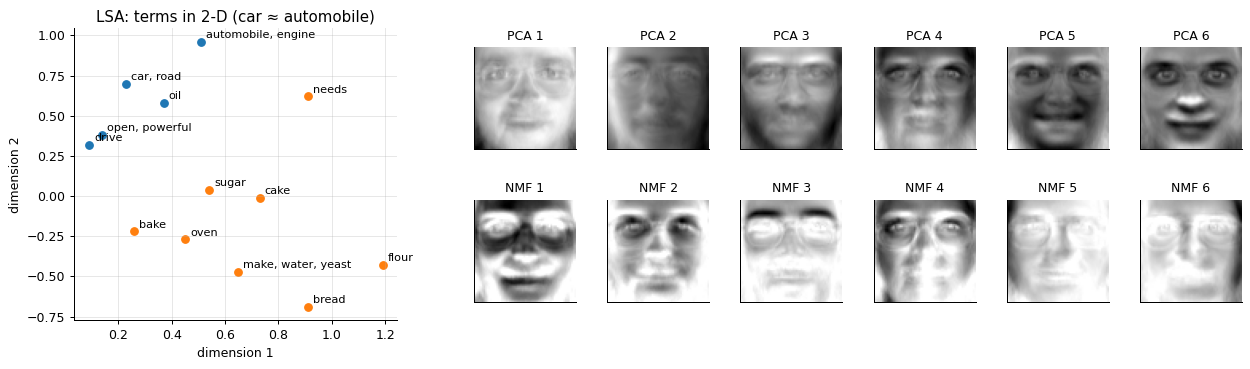

In [20]:
nmf = NMF(n_components=16, init="nndsvda", max_iter=2000, random_state=0)
W_nmf = nmf.fit_transform(Xf); H_nmf = nmf.components_
pca16 = PCA(16, svd_solver="full").fit(Xf)
err_pca16 = np.linalg.norm(Xf - pca16.inverse_transform(pca16.transform(Xf)))
print(f"NMF: {nmf.n_iter_} iterations; min of W and H: {W_nmf.min():.1f}, {H_nmf.min():.1f}")
print(f"reconstruction error ||X - X_hat||_F with k = 16:  PCA {err_pca16:.2f}   NMF {nmf.reconstruction_err_:.2f}")
small = lambda M: np.mean(np.abs(M) < 0.01 * np.abs(M).max(axis=1, keepdims=True))
print(f"share of near-zero pixels in the basis images (< 1% of the image's max):  PCA {small(pca16.components_):.1%}   NMF {small(H_nmf):.1%}")
assert err_pca16 <= nmf.reconstruction_err_

fig = plt.figure(figsize=(14, 4.2))
ax = fig.add_subplot(1, 3, 1)
groups = {}                                                   # terms with identical vectors share one label
for t, v in enumerate(term_vec):
    groups.setdefault(tuple(np.round(v, 2)), []).append(terms[t])
for v, ws in groups.items():
    col = "tab:blue" if ws[0] in ["car", "automobile", "engine", "road", "drive", "oil", "open", "powerful"] else "tab:orange"
    ax.scatter(*v, color=col); ax.annotate(", ".join(ws), v, xytext=(4, 3), textcoords="offset points", fontsize=9)
ax.set_title("LSA: terms in 2-D (car ≈ automobile)"); ax.set_xlabel("dimension 1"); ax.set_ylabel("dimension 2")
for r, (B, lab) in enumerate([(pca16.components_, "PCA"), (H_nmf, "NMF")]):
    for j in range(6):
        a = fig.add_subplot(2, 9, 9 * r + 4 + j)
        show_img(a, B[j].reshape(64, 64), f"{lab} {j+1}", cmap="gray" if lab == "PCA" else "gray_r")
plt.tight_layout(); plt.show()

**What just happened?**
- **LSA.** `TruncatedSVD` is exactly the SVD of the uncentred count matrix (same singular values, 2.496 and 2.319). In raw counts "car" and "automobile" have cosine 0.000: they never appear in the same document. In the 2-D LSA space their cosine is 0.985, because both co-occur with "engine" and "road". "car" and "bread" stay apart (−0.33). This is the ancestor of word embeddings and of the dense retrieval in the RAG part of the course.
- **NMF.** After 1,273 iterations both factors are non-negative. The NMF basis images are localised: 15.5% of their pixels are near zero (below 1% of the image's maximum), against 2.9% for eigenfaces, which spread over the whole face. The price of interpretability is a slightly higher error at equal $k$: 92.15 for PCA, 93.76 for NMF.

## 7. PCA on other matrices: kernel PCA and classical MDS

PCA only needs **inner products**: the scores $\mathbf{U}\boldsymbol{\Sigma}$ are the eigenvectors of the $n \times n$ Gram matrix $\mathbf{X}_c\mathbf{X}_c^\top = \mathbf{U}\boldsymbol{\Sigma}^2\mathbf{U}^\top$, scaled by the square roots of its eigenvalues. Replace that matrix by another one and we get two classic methods.

### 7a. Kernel PCA

Map the points to a feature space, $\boldsymbol{\phi}(\mathbf{x})$, and do PCA there. We never compute $\boldsymbol{\phi}$: a **kernel** gives the inner products directly, $K_{ij} = k(\mathbf{x}_i, \mathbf{x}_j) = \boldsymbol{\phi}(\mathbf{x}_i)^\top\boldsymbol{\phi}(\mathbf{x}_j)$, as in the SVM chapter. Here the RBF kernel $k(\mathbf{x}, \mathbf{x}') = e^{-\gamma\lVert\mathbf{x} - \mathbf{x}'\rVert^2}$. The algorithm:

1. centre in feature space: $\tilde{\mathbf{K}} = \mathbf{J}\mathbf{K}\mathbf{J}$ with $\mathbf{J} = \mathbf{I} - \frac{1}{n}\mathbf{1}\mathbf{1}^\top$ (this is $\boldsymbol{\Phi}_c\boldsymbol{\Phi}_c^\top$);
2. eigen-decompose $\tilde{\mathbf{K}} = \mathbf{A}\,\mathrm{diag}(\mu_1, \mu_2, \dots)\,\mathbf{A}^\top$;
3. scores of the training points: $z_{ij} = \sqrt{\mu_j}\,a_{ij}$ (the analogue of $\mathbf{U}\boldsymbol{\Sigma}$). A new point needs its kernel row against all $n$ training points.

The cost is that of an $n \times n$ eigenproblem, $O(n^3)$, so plain kernel PCA is for a few thousand points (Nyström approximations go further). With the linear kernel $\mathbf{K} = \mathbf{X}\mathbf{X}^\top$ it is ordinary PCA.

In [21]:
Xcir, ycir = make_circles(n_samples=400, factor=0.3, noise=0.05, random_state=0)
n_c = len(Xcir); J = np.eye(n_c) - 1 / n_c

def kernel_pca(K, k):
    Kc = J @ K @ J
    mu, A = np.linalg.eigh(Kc)
    mu, A = mu[::-1], A[:, ::-1]
    return A[:, :k] * np.sqrt(np.clip(mu[:k], 0, None)), mu

gamma = 2.0
K_rbf = np.exp(-gamma * squareform(pdist(Xcir, "sqeuclidean")))
Z_kp, mu_kp = kernel_pca(K_rbf, 2)
Z_kp_sk = KernelPCA(n_components=2, kernel="rbf", gamma=gamma).fit_transform(Xcir)
print("max |ours - sklearn KernelPCA| (sign aligned):", np.abs(flip(Z_kp, Z_kp_sk) - Z_kp_sk).max())
Z_lin, _ = kernel_pca(Xcir @ Xcir.T, 2)
Z_pca_c = PCA(2).fit_transform(Xcir)
print("linear kernel vs PCA:", np.abs(flip(Z_lin, Z_pca_c) - Z_pca_c).max())
assert np.allclose(flip(Z_kp, Z_kp_sk), Z_kp_sk, atol=1e-8) and np.allclose(flip(Z_lin, Z_pca_c), Z_pca_c, atol=1e-8)

lr = LogisticRegression()
print(f"logistic regression on the FIRST component only (5-fold CV): PCA {cross_val_score(lr, Z_pca_c[:, :1], ycir, cv=5).mean():.3f}")
kp_acc = {}
for g in [0.1, 1, 2, 5, 10, 50]:
    Zg = KernelPCA(n_components=1, kernel="rbf", gamma=g).fit_transform(Xcir)
    kp_acc[g] = cross_val_score(lr, Zg, ycir, cv=5).mean()
print("kernel PCA, accuracy by gamma:", {g: round(a, 3) for g, a in kp_acc.items()})

max |ours - sklearn KernelPCA| (sign aligned): 6.8833827526759706e-15
linear kernel vs PCA: 5.218048215738236e-15
logistic regression on the FIRST component only (5-fold CV): PCA 0.450
kernel PCA, accuracy by gamma: {0.1: np.float64(0.44), 1: np.float64(0.465), 2: np.float64(1.0), 5: np.float64(1.0), 10: np.float64(0.755), 50: np.float64(0.705)}


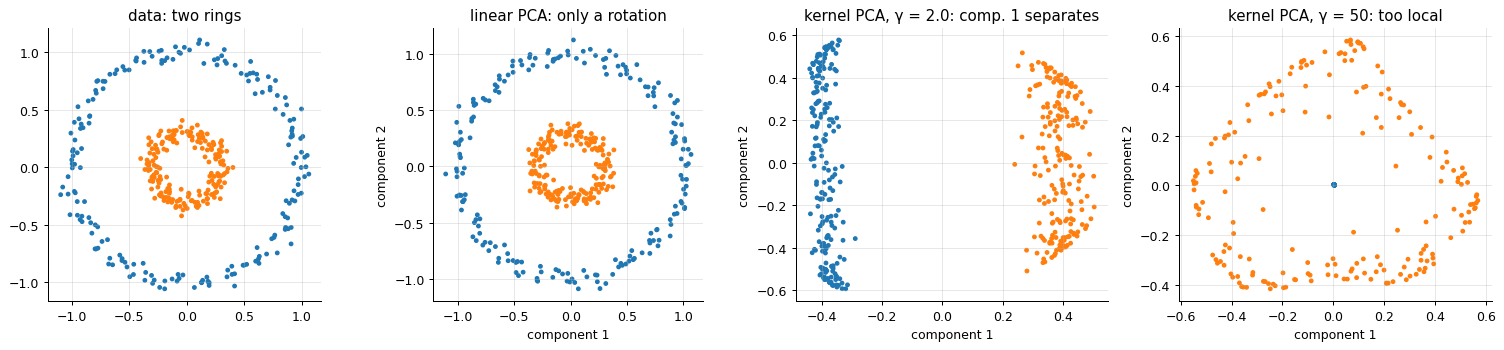

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
cols = np.array(["tab:blue", "tab:orange"])
axes[0].scatter(Xcir[:, 0], Xcir[:, 1], c=cols[ycir], s=8); axes[0].set_aspect("equal"); axes[0].set_title("data: two rings")
axes[1].scatter(Z_pca_c[:, 0], Z_pca_c[:, 1], c=cols[ycir], s=8); axes[1].set_aspect("equal"); axes[1].set_title("linear PCA: only a rotation")
axes[2].scatter(Z_kp[:, 0], Z_kp[:, 1], c=cols[ycir], s=8); axes[2].set_title(f"kernel PCA, γ = {gamma}: comp. 1 separates")
Z50 = KernelPCA(n_components=2, kernel="rbf", gamma=50).fit_transform(Xcir)
axes[3].scatter(Z50[:, 0], Z50[:, 1], c=cols[ycir], s=8); axes[3].set_title("kernel PCA, γ = 50: too local")
for ax in axes[1:]: ax.set_xlabel("component 1"); ax.set_ylabel("component 2")
plt.tight_layout(); plt.show()

**What just happened?** Our kernel PCA matches `KernelPCA` to $10^{-15}$, and with the linear kernel it is exactly PCA. Linear PCA only rotates the rings, so a classifier on its first component is at chance (0.450). With the RBF kernel and $\gamma = 2$ the first component alone separates the rings perfectly (1.000). $\gamma$ is the inverse squared length scale of the kernel: at $\gamma = 0.1$ the kernel barely bends space and we are back near linear PCA (0.440); at $\gamma = 50$ each point only "sees" its immediate neighbours, the components describe small local bumps, and the accuracy falls to 0.705. Like in an SVM, $\gamma$ must be tuned.

### 7b. Classical MDS: coordinates from a table of distances

Sometimes we have only distances, $D_{ij}$: road distances between cities, dissimilarities between proteins. **Classical multidimensional scaling** (Torgerson, 1952) finds points whose Euclidean distances reproduce them.

**Key identity.** If $D_{ij} = \lVert\mathbf{x}_i - \mathbf{x}_j\rVert$, then

$$
\mathbf{B} = -\tfrac{1}{2}\,\mathbf{J}\,\mathbf{D}^{(2)}\,\mathbf{J} = \mathbf{X}_c\mathbf{X}_c^\top, \qquad \mathbf{D}^{(2)}_{ij} = D_{ij}^2 .
$$

*Proof.* $D_{ij}^2 = \lVert\mathbf{x}_i\rVert^2 + \lVert\mathbf{x}_j\rVert^2 - 2\mathbf{x}_i^\top\mathbf{x}_j$. Multiplying by $\mathbf{J}$ on both sides subtracts row and column means: the terms that depend only on $i$ or only on $j$ disappear, and the cross term becomes $-2$ times the centred Gram matrix. $\blacksquare$

So eigen-decompose $\mathbf{B} = \mathbf{U}\boldsymbol{\Lambda}\mathbf{U}^\top$ and take $\mathbf{Z} = \mathbf{U}_k\boldsymbol{\Lambda}_k^{1/2}$: **classical MDS on Euclidean distances is PCA**, up to signs. If the distances are not Euclidean (great-circle distances on a sphere, road distances), $\mathbf{B}$ gets negative eigenvalues, and their size measures how non-Euclidean the table is.

In [23]:
def classical_mds(D, k):
    n = len(D); Jn = np.eye(n) - 1 / n
    B = -0.5 * Jn @ (D ** 2) @ Jn
    lam, U = np.linalg.eigh(B)
    lam, U = lam[::-1], U[:, ::-1]
    return U[:, :k] * np.sqrt(np.clip(lam[:k], 0, None)), lam

Z_mds, _ = classical_mds(squareform(pdist(Xd)), 2)
Z_pca_d = PCA(2).fit_transform(Xd)
print("digits: max |MDS scores - PCA scores| (sign aligned):", np.abs(flip(Z_mds, Z_pca_d) - Z_pca_d).max())
assert np.allclose(flip(Z_mds, Z_pca_d), Z_pca_d, atol=1e-8)

cities = {"A Coruña": (43.36, -8.41), "Barcelona": (41.39, 2.17), "Bilbao": (43.26, -2.93), "Madrid": (40.42, -3.70),
          "Málaga": (36.72, -4.42), "Murcia": (37.98, -1.13), "Pamplona": (42.82, -1.64), "Salamanca": (40.97, -5.66),
          "Sevilla": (37.39, -5.98), "Valencia": (39.47, -0.38), "Valladolid": (41.65, -4.72), "Zaragoza": (41.65, -0.88)}
names_c = list(cities); lat, lon = np.deg2rad(np.array(list(cities.values()))).T
def great_circle(i, j, R=6371.0):                            # haversine formula, km
    a = np.sin((lat[j] - lat[i]) / 2) ** 2 + np.cos(lat[i]) * np.cos(lat[j]) * np.sin((lon[j] - lon[i]) / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))
Dc = np.array([[great_circle(i, j) for j in range(12)] for i in range(12)])
print(f"Madrid-Barcelona {Dc[3, 1]:.0f} km, Pamplona-Sevilla {Dc[6, 8]:.0f} km")
Zc, lam_c = classical_mds(Dc, 2)
true_xy = np.c_[np.rad2deg(lon) * 111.32 * np.cos(np.deg2rad(40)), np.rad2deg(lat) * 110.57]   # km on a flat map
mtx1, mtx2, disparity = procrustes(true_xy, Zc)
print("eigenvalues of B (top 4 and bottom 2):", lam_c[:4].round(0), lam_c[-2:].round(1))
print(f"Procrustes disparity between the MDS map and the true map: {disparity:.5f}  (0 = identical up to rotation, reflection, scale)")

digits: max |MDS scores - PCA scores| (sign aligned): 1.4210854715202004e-13
Madrid-Barcelona 505 km, Pamplona-Sevilla 707 km
eigenvalues of B (top 4 and bottom 2): [700474. 655341.    149.      0.] [-108. -236.]
Procrustes disparity between the MDS map and the true map: 0.00079  (0 = identical up to rotation, reflection, scale)


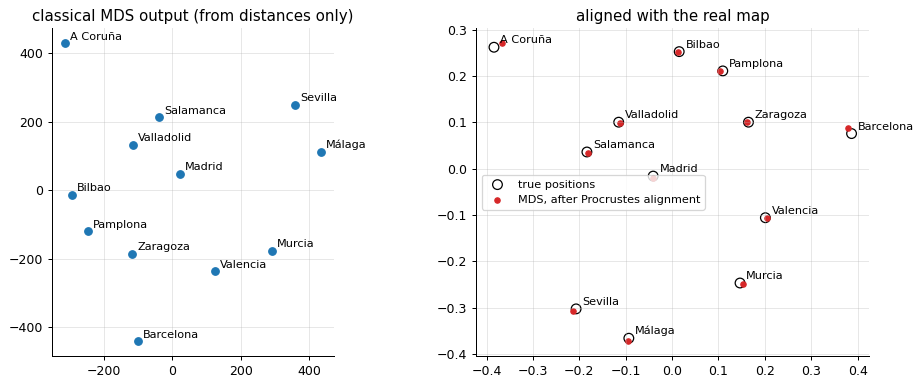

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].scatter(Zc[:, 0], Zc[:, 1], color="tab:blue")
for i, nm in enumerate(names_c): axes[0].annotate(nm, Zc[i], xytext=(4, 3), textcoords="offset points", fontsize=9)
axes[0].set_title("classical MDS output (from distances only)"); axes[0].set_aspect("equal")
axes[1].scatter(mtx1[:, 0], mtx1[:, 1], s=60, facecolors="none", edgecolors="k", label="true positions")
axes[1].scatter(mtx2[:, 0], mtx2[:, 1], color="tab:red", s=18, label="MDS, after Procrustes alignment")
for i, nm in enumerate(names_c): axes[1].annotate(nm, mtx1[i], xytext=(5, 3), textcoords="offset points", fontsize=9)
axes[1].set_aspect("equal"); axes[1].legend(fontsize=9, loc="center left"); axes[1].set_title("aligned with the real map")
plt.tight_layout(); plt.show()

**What just happened?** On the digits, classical MDS on the Euclidean distance table reproduces the PCA scores to $10^{-12}$: same method, different input. From the table of 66 great-circle distances alone (Madrid–Barcelona 505 km), MDS recovers the map of Spain. The output may come rotated or mirrored, since distances do not know where north is; after a Procrustes rotation the disparity is 0.0008. The two top eigenvalues dominate (700,474 and 655,341, then 149), and small negative eigenvalues appear (down to −236): distances on a sphere are not exactly Euclidean in a plane.

**Beyond classical MDS.** *Metric MDS* minimises the **stress** $\sum_{i<j}(D_{ij} - \lVert\mathbf{z}_i - \mathbf{z}_j\rVert)^2$ by gradient descent (`sklearn.manifold.MDS`); *non-metric MDS* keeps only the order of the distances. Isomap, next, is classical MDS on a cleverer distance.

## 8. Manifold learning: Isomap and LLE on the Swiss roll

**Manifold hypothesis.** High-dimensional data often lie near a low-dimensional, *curved* surface (a manifold). Photos of one face under different poses form a surface with a few degrees of freedom (angles, light), even though each photo has thousands of pixels. On a curved surface, the straight-line distance is misleading: two points on neighbouring layers of a rolled-up sheet are close in $\mathbb{R}^3$ but far apart *along* the sheet.

**Isomap** (Tenenbaum et al., 2000) estimates distances along the manifold:

1. build the **$k$-nearest-neighbour graph**, with edges weighted by Euclidean distance (short distances are trustworthy);
2. compute **geodesic** distances as shortest paths in the graph (Dijkstra);
3. run **classical MDS** on the geodesic distances.

**LLE** (locally linear embedding, Roweis and Saul, 2000) keeps local geometry instead: it writes each point as a weighted average of its $k$ neighbours, $\mathbf{x}_i \approx \sum_j w_{ij}\mathbf{x}_j$, then finds low-dimensional points that are reconstructed by the **same** weights, via the bottom eigenvectors of $(\mathbf{I} - \mathbf{W})^\top(\mathbf{I} - \mathbf{W})$.

The data: the **Swiss roll**, 1,500 points on a rolled-up rectangle in 3-D. Its parameter $t$ (the position along the roll) is known, so we can measure whether a method unrolls it: the rank correlation between the first embedding coordinate and $t$.

In [25]:
Xr, t_roll = make_swiss_roll(n_samples=1500, noise=0.05, random_state=0)
G = kneighbors_graph(Xr, n_neighbors=10, mode="distance")      # sparse, 10 neighbours per point
D_geo = shortest_path(G, method="D", directed=False)          # Dijkstra on the undirected graph
Z_iso, lam_iso = classical_mds(D_geo, 2)
Z_iso_sk = Isomap(n_neighbors=10, n_components=2).fit_transform(Xr)
print("max |ours - sklearn Isomap| (sign aligned):", np.abs(flip(Z_iso, Z_iso_sk) - Z_iso_sk).max(), " (coordinates up to", np.abs(Z_iso_sk).max().round(1), ")")
assert np.allclose(flip(Z_iso, Z_iso_sk), Z_iso_sk, atol=1e-6)

i0, i1 = t_roll.argmin(), t_roll.argmax()                     # inner and outer end of the roll
print(f"between the two ends: Euclidean {np.linalg.norm(Xr[i0] - Xr[i1]):.1f}, geodesic {D_geo[i0, i1]:.1f}")
Z_pca_r = PCA(2).fit_transform(Xr)
Z_lle = LocallyLinearEmbedding(n_neighbors=12, n_components=2, random_state=0).fit_transform(Xr)
rho = lambda Z: max(abs(spearmanr(Z[:, 0], t_roll)[0]), abs(spearmanr(Z[:, 1], t_roll)[0]))
print(f"|Spearman correlation| of the best coordinate with t:  PCA {rho(Z_pca_r):.3f}   Isomap {rho(Z_iso):.4f}   LLE {rho(Z_lle):.4f}")
rho_k = {}
for k in [5, 10, 20, 30, 40]:
    rho_k[k] = rho(Isomap(n_neighbors=k, n_components=2).fit_transform(Xr))
print("Isomap, correlation with t by number of neighbours:", {k: round(v, 3) for k, v in rho_k.items()})

max |ours - sklearn Isomap| (sign aligned): 6.998845947236987e-13  (coordinates up to 53.6 )
between the two ends: Euclidean 19.0, geodesic 92.6
|Spearman correlation| of the best coordinate with t:  PCA 0.213   Isomap 0.9999   LLE 0.9999


Isomap, correlation with t by number of neighbours: {5: np.float64(1.0), 10: np.float64(1.0), 20: np.float64(1.0), 30: np.float64(0.746), 40: np.float64(0.273)}


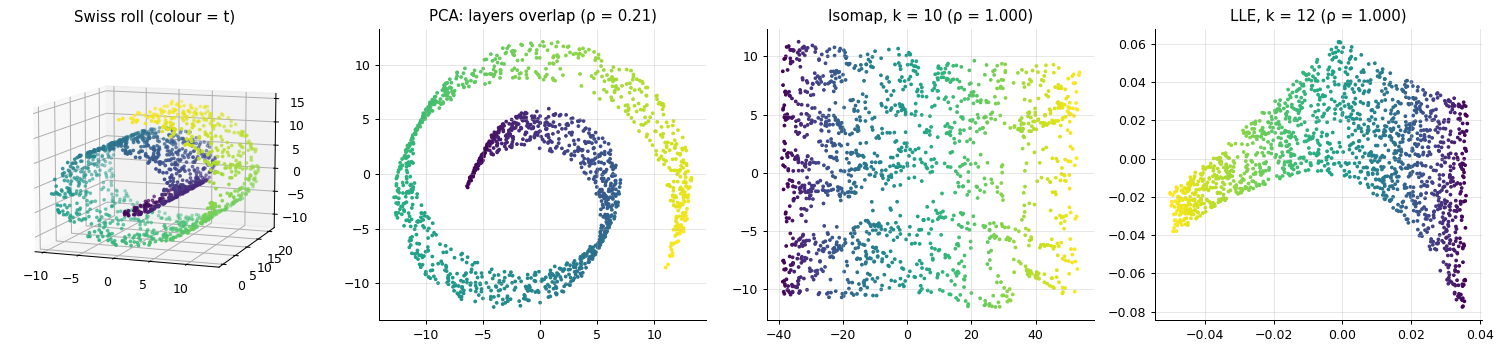

In [26]:
fig = plt.figure(figsize=(17, 4))
ax = fig.add_subplot(1, 4, 1, projection="3d")
ax.scatter(Xr[:, 0], Xr[:, 1], Xr[:, 2], c=t_roll, cmap="viridis", s=4); ax.view_init(10, -70)
ax.set_title("Swiss roll (colour = t)")
for p, (Z, title) in enumerate([(Z_pca_r, f"PCA: layers overlap (ρ = {rho(Z_pca_r):.2f})"),
                                (Z_iso, f"Isomap, k = 10 (ρ = {rho(Z_iso):.3f})"),
                                (Z_lle, f"LLE, k = 12 (ρ = {rho(Z_lle):.3f})")], start=2):
    a = fig.add_subplot(1, 4, p); a.scatter(Z[:, 0], Z[:, 1], c=t_roll, cmap="viridis", s=4); a.set_title(title)
plt.tight_layout(); plt.show()

**What just happened?** Our three-step Isomap matches scikit-learn's to rounding. The two ends of the roll are 19.0 apart in a straight line but 92.6 along the sheet. PCA can only project the roll flat, so the layers land on top of each other and the best coordinate correlates 0.213 with $t$. Isomap unrolls it into a rectangle (0.9999). LLE also orders the points by $t$ (0.9999) but bends the rectangle into a curved wedge with very uneven spacing, a known weakness of LLE.

**Short circuits.** With 10 or 20 neighbours Isomap is near perfect (1.000 and 1.000); with 30 the correlation drops to 0.746 and with 40 to 0.273. Too many neighbours create graph edges that jump between layers of the roll, and one such shortcut ruins all the geodesic distances that pass through it. Manifold methods are sensitive to $k$ and to noise; always look at the result with more than one setting.

## 9. t-SNE from scratch, and the effect of the perplexity

Isomap tries to keep **all** geodesic distances, which is hard when the data have many clusters or a complicated shape. **t-SNE** (van der Maaten and Hinton, 2008) only tries to keep **neighbourhoods**: who is close to whom.

**High-D similarities.** For each point $i$, a Gaussian centred at $\mathbf{x}_i$ turns distances into probabilities of picking $j$ as a neighbour:

$$
p_{j\mid i} = \frac{\exp(-\lVert\mathbf{x}_i - \mathbf{x}_j\rVert^2 / 2\sigma_i^2)}{\sum_{l \ne i}\exp(-\lVert\mathbf{x}_i - \mathbf{x}_l\rVert^2 / 2\sigma_i^2)}, \qquad
p_{ij} = \frac{p_{j\mid i} + p_{i\mid j}}{2n} .
$$

Each $\sigma_i$ is set by binary search so that the **perplexity** $2^{H(P_i)}$, with $H(P_i) = -\sum_j p_{j\mid i}\log_2 p_{j\mid i}$, equals a user value (typically 5 to 50). Perplexity is a smooth "number of neighbours": in a dense region $\sigma_i$ shrinks, in a sparse one it grows.

**Low-D similarities** use a Student-t with one degree of freedom (a Cauchy), which has heavy tails:

$$
q_{ij} = \frac{(1 + \lVert\mathbf{z}_i - \mathbf{z}_j\rVert^2)^{-1}}{\sum_{l \ne m}(1 + \lVert\mathbf{z}_l - \mathbf{z}_m\rVert^2)^{-1}} .
$$

**Objective and gradient.** Minimise $\mathrm{KL}(P\Vert Q) = \sum_{i \ne j}p_{ij}\log\frac{p_{ij}}{q_{ij}}$ by gradient descent on the $\mathbf{z}_i$:

$$
\frac{\partial\,\mathrm{KL}}{\partial\mathbf{z}_i} = 4\sum_j(p_{ij} - q_{ij})\,(1 + \lVert\mathbf{z}_i - \mathbf{z}_j\rVert^2)^{-1}(\mathbf{z}_i - \mathbf{z}_j) .
$$

Read it as springs: if $p_{ij} > q_{ij}$ (neighbours in high-D that are too far apart in the map) $j$ **attracts** $i$; if $p_{ij} < q_{ij}$ it **repels** it.

**Asymmetry.** KL punishes a large $p_{ij}$ modelled by a small $q_{ij}$ (true neighbours torn apart) much more than the reverse (far points placed close). So t-SNE keeps local neighbourhoods faithfully and is free to distort large distances.

**Why the heavy tail (crowding problem).** In 10-D a point can have 11 equidistant neighbours; in 2-D only 3. There is not enough room in 2-D to place moderately distant points at moderate distances. The Cauchy kernel decays like $1/r^2$ instead of $e^{-r^2}$: to get the same small $q_{ij}$, two points must be placed **much farther apart**, which makes room and separates clusters.

**Tricks**: early exaggeration (multiply $P$ by 12 for the first 250 iterations so clusters form), momentum, and per-parameter gains.

In [27]:
def cond_probs(D2, perplexity, tol=1e-5, max_iter=100):
    """p_{j|i} for every i, with beta_i = 1 / (2 sigma_i^2) found by binary search on the entropy."""
    n = len(D2); P = np.zeros((n, n)); target = np.log(perplexity); beta = np.ones(n)
    for i in range(n):
        d = np.delete(D2[i], i); lo, hi, b = 0.0, np.inf, 1.0
        for _ in range(max_iter):
            w = np.exp(-(d - d.min()) * b); p = w / w.sum()
            H = -np.sum(p * np.log(np.maximum(p, 1e-300)))      # entropy in nats; perplexity = e^H = 2^(H in bits)
            if abs(H - target) < tol: break
            if H > target: lo = b; b = b * 2 if hi == np.inf else (b + hi) / 2
            else: hi = b; b = (b + lo) / 2
        P[i, np.arange(n) != i] = p; beta[i] = b
    return P, beta

def tsne_grad(P, Z):
    d2 = squareform(pdist(Z, "sqeuclidean"))
    Wk = 1 / (1 + d2); np.fill_diagonal(Wk, 0)
    Q = Wk / Wk.sum()
    M = (P - Q) * Wk
    return 4 * (np.diag(M.sum(1)) - M) @ Z, Q              # row i: 4 sum_j M_ij (z_i - z_j)

def kl(P, Q):
    m = P > 0
    return np.sum(P[m] * np.log(P[m] / np.maximum(Q[m], 1e-300)))

def tsne(X, perplexity=30.0, n_iter=1000, seed=0, exag=12.0, exag_iter=250):
    n = len(X)
    Pc, _ = cond_probs(squareform(pdist(X, "sqeuclidean")), perplexity)
    P = np.maximum((Pc + Pc.T) / (2 * n), 1e-12)
    lr = max(n / exag / 4, 50)                               # the "auto" learning rate of sklearn
    r = np.random.default_rng(seed)
    Z = 1e-4 * r.standard_normal((n, 2)); V = np.zeros_like(Z); gains = np.ones_like(Z); hist = []
    for it in range(n_iter):
        e = exag if it < exag_iter else 1.0
        g, Q = tsne_grad(e * P, Z)
        gains = np.where(np.sign(g) != np.sign(V), gains + 0.2, gains * 0.8).clip(0.01)
        V = (0.5 if it < exag_iter else 0.8) * V - lr * gains * g
        Z = Z + V; Z -= Z.mean(0)
        if it % 10 == 0 or it == n_iter - 1:
            hist.append((it, kl(P, Q)))
    return Z, P, np.array(hist)

# 1) the binary search hits the perplexity for every point
sub = np.sort(np.concatenate([np.random.default_rng(1).choice(np.where(yd == c)[0], 60, replace=False) for c in range(10)]))
Xs, ys = Xd[sub], yd[sub]
Pc30, beta30 = cond_probs(squareform(pdist(Xs, "sqeuclidean")), 30)
H = -np.sum(np.where(Pc30 > 0, Pc30 * np.log(np.maximum(Pc30, 1e-300)), 0), axis=1)
print(f"{len(Xs)} digits (60 per class): achieved perplexity from {np.exp(H).min():.4f} to {np.exp(H).max():.4f} (target 30)")
sig = 1 / np.sqrt(2 * beta30)
print(f"sigma_i ranges from {sig.min():.2f} to {sig.max():.2f}: dense regions get a narrow Gaussian")
assert np.allclose(np.exp(H), 30, atol=1e-3)

# 2) the analytic gradient matches finite differences (tiny problem)
r0 = np.random.default_rng(0); Pt = r0.random((15, 15)); Pt = Pt + Pt.T; np.fill_diagonal(Pt, 0); Pt /= Pt.sum()
Zt0 = r0.standard_normal((15, 2)); g_an, _ = tsne_grad(Pt, Zt0); g_num = np.zeros_like(Zt0); h = 1e-6
for i in range(15):
    for c in range(2):
        Zp, Zm = Zt0.copy(), Zt0.copy(); Zp[i, c] += h; Zm[i, c] -= h
        g_num[i, c] = (kl(Pt, tsne_grad(Pt, Zp)[1]) - kl(Pt, tsne_grad(Pt, Zm)[1])) / (2 * h)
rel = np.abs(g_an - g_num).max() / np.abs(g_num).max()
print(f"gradient check: max relative error {rel:.1e}")
assert rel < 1e-5

600 digits (60 per class): achieved perplexity from 29.9997 to 30.0003 (target 30)
sigma_i ranges from 7.41 to 13.94: dense regions get a narrow Gaussian
gradient check: max relative error 2.5e-09


from scratch: final KL 0.473 in 1.8 s   |   sklearn (exact): KL 0.468 in 3.9 s


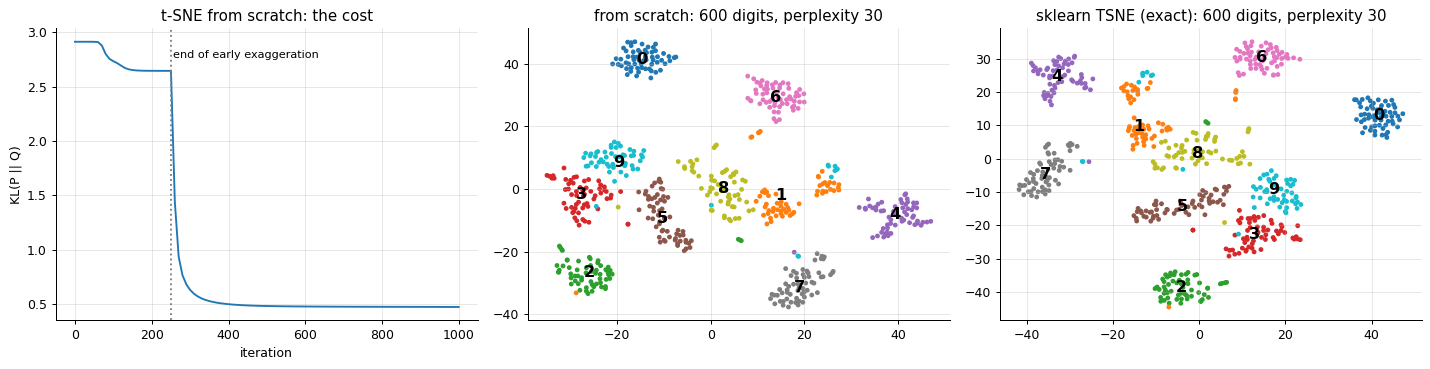

In [28]:
t0 = time.time()
Z_ts, P_ts, hist_ts = tsne(Xs, perplexity=30)
t_scratch = time.time() - t0
t0 = time.time()
ts_sk = TSNE(n_components=2, perplexity=30, method="exact", init="random", random_state=0)
Z_ts_sk = ts_sk.fit_transform(Xs)
t_sk = time.time() - t0
print(f"from scratch: final KL {hist_ts[-1, 1]:.3f} in {t_scratch:.1f} s   |   sklearn (exact): KL {ts_sk.kl_divergence_:.3f} in {t_sk:.1f} s")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].plot(hist_ts[:, 0], hist_ts[:, 1]); axes[0].axvline(250, color="gray", ls=":")
axes[0].text(255, hist_ts[:, 1].max() * 0.95, "end of early exaggeration", fontsize=9)
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("KL(P || Q)"); axes[0].set_title("t-SNE from scratch: the cost")
for ax, Z, title in [(axes[1], Z_ts, "from scratch"), (axes[2], Z_ts_sk, "sklearn TSNE (exact)")]:
    ax.scatter(Z[:, 0], Z[:, 1], c=ys, cmap="tab10", s=8)
    for c in range(10):
        m = np.median(Z[ys == c], axis=0); ax.text(m[0], m[1], str(c), fontsize=13, weight="bold", ha="center", va="center")
    ax.set_title(f"{title}: 600 digits, perplexity 30")
plt.tight_layout(); plt.show()

Now scikit-learn on all 1,797 digits (Barnes–Hut approximation, $O(n\log n)$ per iteration, PCA initialisation) with three perplexities.

perplexity   5:   1.9 s, KL 0.944


perplexity  30:   2.4 s, KL 0.754


perplexity 100:   3.9 s, KL 0.594


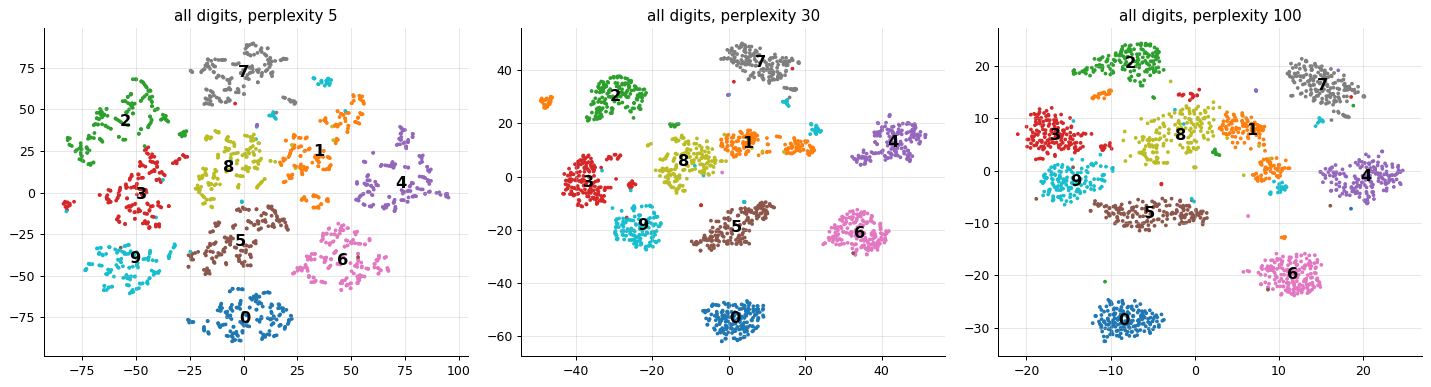

In [29]:
emb_perp, t_perp, kl_perp = {}, {}, {}
for perp in [5, 30, 100]:
    t0 = time.time()
    ts = TSNE(n_components=2, perplexity=perp, init="pca", random_state=0)
    emb_perp[perp] = ts.fit_transform(Xd)
    t_perp[perp], kl_perp[perp] = time.time() - t0, ts.kl_divergence_
    print(f"perplexity {perp:3d}: {t_perp[perp]:5.1f} s, KL {kl_perp[perp]:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for ax, perp in zip(axes, [5, 30, 100]):
    Z = emb_perp[perp]; ax.scatter(Z[:, 0], Z[:, 1], c=yd, cmap="tab10", s=4)
    for c in range(10):
        m = np.median(Z[yd == c], axis=0); ax.text(m[0], m[1], str(c), fontsize=13, weight="bold", ha="center", va="center")
    ax.set_title(f"all digits, perplexity {perp}")
plt.tight_layout(); plt.show()

**What just happened?** The binary search reaches perplexity 30 for every point (from 29.9997 to 30.0003), with $\sigma_i$ between 7.41 and 13.94: each point gets its own scale. The analytic gradient agrees with finite differences to $3 \cdot 10^{-9}$ (relative). Our 50-line t-SNE reaches a KL of 0.473 in a few seconds, close to scikit-learn's exact implementation (0.468), and both maps separate the ten digits; the layouts differ because the random starts and the optimisers differ.

**Perplexity.** At perplexity 5 every point only cares about ~5 neighbours: the map breaks into many small clumps. At 30, the default, the ten digits form clean islands. At 100 the islands are rounder and pushed together, with more global arrangement but less local detail; the run time grows with the perplexity. The KL values (0.944, 0.754, 0.594) are **not** comparable across perplexities, because $P$ changes. There is no right perplexity; try several. Section 10 measures which map keeps neighbours best.

## 10. Reading embeddings honestly

### 10a. What a t-SNE plot does not show

Three experiments on 2-D data, where we can see the truth:

1. **Cluster sizes**: two Gaussian clusters, one 10 times wider than the other.
2. **Distances between clusters**: three clusters on a line, the third 5 times farther away.
3. **Randomness**: the same digits with different random seeds.

In [30]:
r1 = np.random.default_rng(3)
X_size = np.r_[r1.normal(0, 1.0, (150, 2)), r1.normal(0, 0.1, (150, 2)) + [10, 0]]
y_size = np.repeat([0, 1], 150)
X_dist = np.r_[r1.normal(0, 1, (100, 2)), r1.normal(0, 1, (100, 2)) + [10, 0], r1.normal(0, 1, (100, 2)) + [60, 0]]
y_dist = np.repeat([0, 1, 2], 100)
E_size = TSNE(perplexity=30, init="pca", random_state=0).fit_transform(X_size)
E_dist = TSNE(perplexity=30, init="pca", random_state=0).fit_transform(X_dist)

spread = lambda Z, m: np.sqrt(((Z[m] - Z[m].mean(0)) ** 2).sum(1).mean())
print(f"cluster sizes:   wide / narrow spread in the data {spread(X_size, y_size == 0) / spread(X_size, y_size == 1):.1f},  "
      f"in the t-SNE map {spread(E_size, y_size == 0) / spread(E_size, y_size == 1):.2f}")
cen = lambda Z, y: np.array([Z[y == c].mean(0) for c in range(3)])
cd, ce = cen(X_dist, y_dist), cen(E_dist, y_dist)
gap = lambda C: np.linalg.norm(C[2] - C[1]) / np.linalg.norm(C[1] - C[0])
print(f"cluster gaps:    gap(B,C) / gap(A,B) in the data {gap(cd):.1f},  in the t-SNE map {gap(ce):.2f}")

E_seed = {s: TSNE(perplexity=30, init="random", random_state=s).fit_transform(Xd) for s in [0, 1]}
print(f"two random seeds on all digits: Procrustes disparity between the maps {procrustes(E_seed[0], E_seed[1])[2]:.3f}  (0 = same up to rotation)")
for s in [0, 1]:
    C = np.array([E_seed[s][yd == c].mean(0) for c in range(10)])
    print(f"   seed {s}: the island nearest to the 0s is the {np.linalg.norm(C - C[0], axis=1).argsort()[1]}s")

cluster sizes:   wide / narrow spread in the data 10.5,  in the t-SNE map 0.89
cluster gaps:    gap(B,C) / gap(A,B) in the data 4.9,  in the t-SNE map 1.02


two random seeds on all digits: Procrustes disparity between the maps 0.754  (0 = same up to rotation)
   seed 0: the island nearest to the 0s is the 2s
   seed 1: the island nearest to the 0s is the 7s


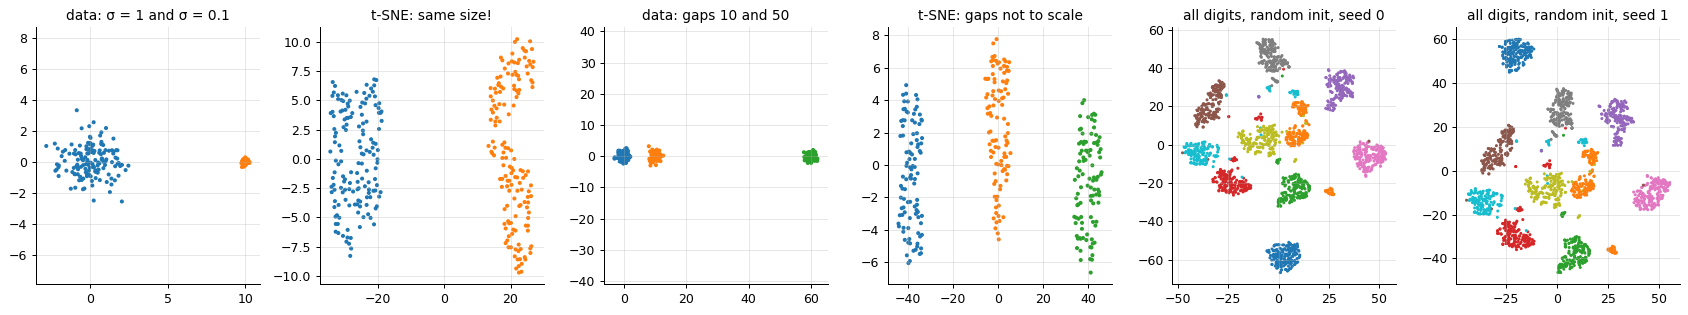

In [31]:
fig, axes = plt.subplots(1, 6, figsize=(19, 3.6))
cl = np.array(["tab:blue", "tab:orange", "tab:green"])
for ax, Z, y, title in [(axes[0], X_size, y_size, "data: σ = 1 and σ = 0.1"), (axes[1], E_size, y_size, "t-SNE: same size!"),
                        (axes[2], X_dist, y_dist, "data: gaps 10 and 50"), (axes[3], E_dist, y_dist, "t-SNE: gaps not to scale")]:
    ax.scatter(Z[:, 0], Z[:, 1], c=cl[y], s=5); ax.set_title(title, fontsize=11)
    if ax in (axes[0], axes[2]): ax.set_aspect("equal", adjustable="datalim")
for ax, s in zip(axes[4:], [0, 1]):
    ax.scatter(E_seed[s][:, 0], E_seed[s][:, 1], c=yd, cmap="tab10", s=2); ax.set_title(f"all digits, random init, seed {s}", fontsize=11)
plt.tight_layout(); plt.show()

**What just happened?**
- **Sizes lie.** In the data the wide cluster is 10.5 times wider than the narrow one; in the t-SNE map the ratio is 0.89: the narrow cluster even looks a little larger. Each $\sigma_i$ adapts to the local density so that every point has ~30 effective neighbours, which erases density differences.
- **Distances between clusters lie.** Cluster C is 5 times farther from B than B is from A (ratio 4.9 in the data), but in the map the ratio is 1.02: the three clusters look equally spaced. Once clusters are separated, the heavy-tailed kernel and the KL asymmetry put little pressure on large distances.
- **Randomness.** With random initialisation, two seeds give maps that differ by much more than a rotation (Procrustes disparity 0.754): the island nearest to the 0s is the 2s with seed 0 and the 7s with seed 1. Positions, orientations and the arrangement of the islands are arbitrary; only the neighbourhoods are meaningful. (The default `init="pca"` makes runs reproducible, not more truthful.)

So read a t-SNE plot for *which points are together*, not for sizes, densities, or how far apart clusters are. Topologies (holes, rings) can also be created or destroyed by the choice of perplexity.

### 10b. Measuring an embedding: kNN preservation

A quantitative check beats a pretty picture. The **kNN preservation** (also *neighbourhood hit*) of an embedding is the average share of each point's $k$ nearest neighbours in the original space that are also among its $k$ nearest neighbours in the embedding:

$$
Q_k = \frac{1}{nk}\sum_{i=1}^n\big|\,\mathcal{N}_k^{\text{high}}(i) \cap \mathcal{N}_k^{\text{low}}(i)\,\big| \in [0, 1] .
$$

$Q_k = 1$ means every neighbourhood is kept; a random map scores about $k/(n-1)$. scikit-learn's `trustworthiness` is a related score: it penalises points that become neighbours in the map without being neighbours in the data, weighted by their rank. For **global** structure we use the Spearman correlation between all pairwise distances before and after (for the Swiss roll, "before" means on the unrolled sheet, which we know exactly).

In [32]:
def knn_preservation(X_high, X_low, k=10):
    """Share of the k nearest neighbours in the original space kept in the embedding (the point itself excluded)."""
    nn_h = NearestNeighbors(n_neighbors=k + 1).fit(X_high).kneighbors(X_high, return_distance=False)[:, 1:]
    nn_l = NearestNeighbors(n_neighbors=k + 1).fit(X_low).kneighbors(X_low, return_distance=False)[:, 1:]
    return np.mean([len(set(a) & set(b)) for a, b in zip(nn_h, nn_l)]) / k

print("sanity: identity map", knn_preservation(Xd, Xd), "| random 2-D map", round(knn_preservation(Xd, rng.standard_normal((n_d, 2))), 4),
      "(expected about k/(n-1) =", round(10 / (n_d - 1), 4), ")")
assert knn_preservation(Xd, Xd) == 1.0

emb_d = {"PCA": PCA(2).fit_transform(Xd), "Isomap": Isomap(n_neighbors=10, n_components=2).fit_transform(Xd), "t-SNE": emb_perp[30]}
emb_r = {"PCA": Z_pca_r, "Isomap": Z_iso, "t-SNE": TSNE(perplexity=30, init="pca", random_state=0).fit_transform(Xr)}
arc = 0.5 * (t_roll * np.sqrt(1 + t_roll ** 2) + np.arcsinh(t_roll))      # arc length along the spiral
sheet = np.c_[arc, Xr[:, 1]]                                             # the true, unrolled 2-D coordinates
rows = []
for data_name, X_, embs in [("digits", Xd, emb_d), ("Swiss roll", Xr, emb_r)]:
    dh = pdist(X_) if data_name == "digits" else pdist(sheet)           # global reference: 64-D distances / distances on the sheet
    for m, Z in embs.items():
        rows.append((data_name, m, knn_preservation(X_, Z, 10), trustworthiness(X_, Z, n_neighbors=10), spearmanr(dh, pdist(Z))[0]))
print(f"\n{'data':12s}{'method':8s}{'kNN pres. (k=10)':>18s}{'trustworthiness':>17s}{'global dist. corr.':>20s}")
for r_ in rows:
    print(f"{r_[0]:12s}{r_[1]:8s}{r_[2]:18.3f}{r_[3]:17.3f}{r_[4]:20.3f}")
knn_perp = {p: knn_preservation(Xd, emb_perp[p]) for p in [5, 30, 100]}
print("\ndigits, t-SNE kNN preservation by perplexity:", {p: round(v, 3) for p, v in knn_perp.items()})

sanity: identity map 1.0 | random 2-D map 0.0057 (expected about k/(n-1) = 0.0056 )



data        method    kNN pres. (k=10)  trustworthiness  global dist. corr.
digits      PCA                  0.118            0.830               0.582
digits      Isomap               0.181            0.837               0.502
digits      t-SNE                0.584            0.993               0.510
Swiss roll  PCA                  0.409            0.975               0.376
Swiss roll  Isomap               0.853            0.999               0.999
Swiss roll  t-SNE                0.859            1.000               0.886

digits, t-SNE kNN preservation by perplexity: {5: np.float64(0.543), 30: np.float64(0.584), 100: np.float64(0.541)}


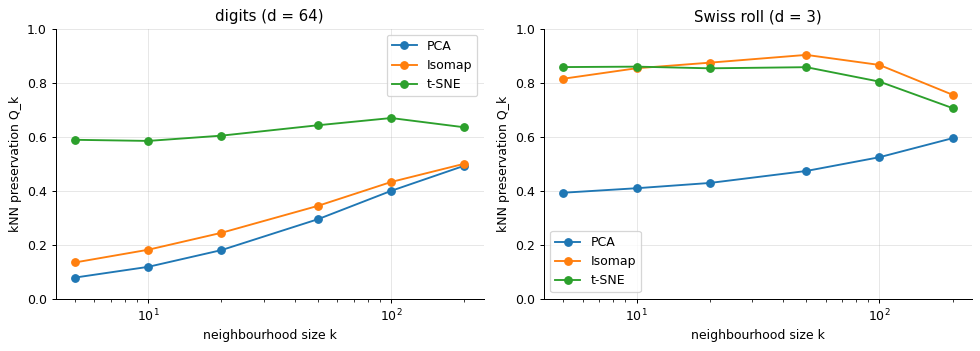

In [33]:
ks_q = [5, 10, 20, 50, 100, 200]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, X_, embs, title in [(axes[0], Xd, emb_d, "digits (d = 64)"), (axes[1], Xr, emb_r, "Swiss roll (d = 3)")]:
    for m, Z in embs.items():
        ax.plot(ks_q, [knn_preservation(X_, Z, k) for k in ks_q], "o-", label=m)
    ax.set_xscale("log"); ax.set_xlabel("neighbourhood size k"); ax.set_ylabel("kNN preservation Q_k"); ax.set_ylim(0, 1)
    ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()

**Interpretation.** On the digits t-SNE keeps by far the most neighbours (0.584 of the 10 nearest, against 0.181 for Isomap and 0.118 for PCA; trustworthiness 0.993 against 0.837 and 0.830), and perplexity 30 is the best of the three we tried (0.543, 0.584, 0.541). But PCA keeps the **global** arrangement best (distance correlation 0.582 against 0.510 for t-SNE and 0.502 for Isomap). On the Swiss roll, a true 2-D manifold, Isomap and t-SNE keep the same share of neighbours (0.853 and 0.859), but only Isomap also keeps the geometry of the unrolled sheet (distance correlation 0.999, against 0.886 for t-SNE and 0.376 for PCA). There is no single best method: it depends on whether you care about local neighbourhoods or global geometry, and on the shape of the data.

### 10c. Practice: fit the reduction on the training data only

Dimensionality reduction is a learned transformation, so it belongs **inside** the cross-validation, like a scaler. For an unsupervised method (PCA) fitting on all the data leaks a little information about the test points. For a **supervised** reduction (LDA, or selecting the features most correlated with the label) the leak can be dramatic. Pure noise makes it obvious: 60 examples, 2,000 random features, random labels; no method can beat 50%. The supervised reduction: keep the 20 features most correlated with the label (`SelectKBest`, the simplest supervised reduction).

In [34]:
r2 = np.random.default_rng(0)
X_noise, y_noise = r2.standard_normal((60, 2000)), r2.integers(0, 2, 60)
leaky = SelectKBest(f_classif, k=20).fit_transform(X_noise, y_noise)    # keeps the 20 features most related to ALL labels
acc_leak = cross_val_score(LogisticRegression(), leaky, y_noise, cv=5).mean()
acc_ok = cross_val_score(make_pipeline(SelectKBest(f_classif, k=20), LogisticRegression()), X_noise, y_noise, cv=5).mean()
print(f"pure noise, 5-fold CV accuracy:  selection on all data first {acc_leak:.3f}   |   selection inside the pipeline {acc_ok:.3f}")

pc_leak = PCA(20).fit_transform(Xd)
acc_pca_leak = cross_val_score(LogisticRegression(max_iter=2000), pc_leak, yd, cv=5).mean()
acc_pca_ok = cross_val_score(make_pipeline(PCA(20), LogisticRegression(max_iter=2000)), Xd, yd, cv=5).mean()
print(f"digits, PCA(20) + logistic regression:  PCA fitted on all data {acc_pca_leak:.3f}   |   inside the pipeline {acc_pca_ok:.3f}")
print(f"\nwhole notebook: {(time.time() - T_START) / 60:.1f} min on cpu")

pure noise, 5-fold CV accuracy:  selection on all data first 0.950   |   selection inside the pipeline 0.500


digits, PCA(20) + logistic regression:  PCA fitted on all data 0.895   |   inside the pipeline 0.896

whole notebook: 0.6 min on cpu


**What just happened?** On pure noise, selecting the features on all 60 examples before the cross-validation gives an accuracy of 0.950: among 2,000 random features some are correlated with *these* 60 random labels by chance, including the labels of the future test folds. Inside the pipeline, where the selection only sees each training fold, the honest accuracy is 0.500, chance level. With unsupervised PCA on the digits there is no visible difference (0.895 vs 0.896), but the rule is the same: **fit every transformation on the training data only** (a scikit-learn `Pipeline` does it for you), and never choose $k$ or the perplexity by looking at test performance.

**Other practical rules.** Scale features with different units before PCA (section 3). For t-SNE on very high-dimensional data, reduce to about 50 dimensions with PCA first: it removes noise and speeds up the distance computations. t-SNE has no `transform` for new points (UMAP and parametric t-SNE do). Use the embedding for *looking*; use PCA scores or a supervised model for *predicting*.

## 11. Summary

- **Curse of dimensionality**: for independent coordinates the relative spread of squared distances is $\propto 1/\sqrt d$ ($1.183/\sqrt d$ for uniform data); the farthest / nearest ratio fell from 86.5 in 2-D to 1.11 in 1000-D.
- **PCA**: maximum variance = minimum reconstruction error ($\operatorname{tr}\mathbf{S}$ = captured + error). Lagrange: $\mathbf{S}\mathbf{w} = \lambda\mathbf{w}$, captured variance $\lambda$. With $k$ components the error is $\sum_{j>k}\lambda_j$.
- **Algorithms**: eigenvectors of $\mathbf{S}$, or the SVD $\mathbf{X}_c = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^\top$ with $\lambda_j = \sigma_j^2/(n-1)$ and $\mathbf{Z} = \mathbf{U}_k\boldsymbol{\Sigma}_k$. Prefer the SVD; signs are arbitrary.
- **Choosing $k$ and scaling**: scree plot, cumulative threshold, Kaiser, or cross-validation. Standardise features with different units (wine: PC1 = proline with 99.8% before, 36.2% after). Whitening $\mathbf{Z}\boldsymbol{\Lambda}_k^{-1/2}$ gives identity covariance.
- **Images**: digits need 21 of 64 components for 90% of the variance, faces 66 of 4,096. Projecting noisy digits on $k$ = 18 components cut the MSE from 16 to 6.9.
- **Random projections**: ratio of squared distances $\sim\chi^2_k/k$, std $\sqrt{2/k}$; JL: $k \ge 4\ln n/(\varepsilon^2/2 - \varepsilon^3/3)$, independent of $d$ (1,383 for 400 faces, $\varepsilon = 0.2$; worst pair 0.168).
- **LDA**: maximise $\mathbf{w}^\top\mathbf{S}_B\mathbf{w}/\mathbf{w}^\top\mathbf{S}_W\mathbf{w}$, at most $C-1$ directions, supervised. **LSA**: truncated SVD of uncentred sparse counts. **NMF**: $\mathbf{X} \approx \mathbf{W}\mathbf{H}$, non-negative, parts-based.
- **Kernel PCA**: eigenvectors of $\mathbf{J}\mathbf{K}\mathbf{J}$, scores $\sqrt{\mu_j}\mathbf{a}_j$; separates the rings with $\gamma = 2$. **Classical MDS**: $\mathbf{B} = -\frac12\mathbf{J}\mathbf{D}^{(2)}\mathbf{J} = \mathbf{X}_c\mathbf{X}_c^\top$, equal to PCA on Euclidean distances; recovers a map from distances.
- **Isomap** = kNN graph + shortest paths + classical MDS; unrolls the Swiss roll (ρ 0.9999 vs 0.21 for PCA), but short-circuits with too many neighbours. **LLE** keeps local reconstruction weights.
- **t-SNE**: Gaussian $p_{j\mid i}$ with $\sigma_i$ set by the perplexity, Student-t $q_{ij}$, minimise $\mathrm{KL}(P\Vert Q)$; gradient $4\sum_j(p_{ij} - q_{ij})(1 + \lVert\mathbf{z}_i - \mathbf{z}_j\rVert^2)^{-1}(\mathbf{z}_i - \mathbf{z}_j)$. Keeps neighbourhoods; cluster sizes, gaps and positions are not meaningful.
- **Measuring**: kNN preservation $Q_{10}$ on the digits: t-SNE 0.584, Isomap 0.181, PCA 0.118; global distance correlation favours PCA. **Practice**: scale first, fit on the training folds only (noise + leaky feature selection: 0.95 instead of 0.50), PCA before t-SNE.

## Exercises

Try each one before opening the answer.

1. **PCA by hand.** A centred 2-D dataset has covariance $\mathbf{S} = \begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix}$. Find the principal directions, the explained variance ratios, and the reconstruction error with $k = 1$.
2. **Scores from the SVD.** Show that $\mathbf{Z} = \mathbf{X}_c\mathbf{V}_k = \mathbf{U}_k\boldsymbol{\Sigma}_k$ and that the scores are uncorrelated, with variances $\lambda_1, \dots, \lambda_k$.
3. **Units.** Feature 1 is a length in metres; we change it to millimetres. What happens to $\mathbf{S}$ and to the first principal direction? What does standardising do to $\mathbf{S}$?
4. **Johnson–Lindenstrauss.** How many dimensions does the JL bound require for $n = 10^6$ points and $\varepsilon = 0.1$? What if the points live in $d = 10^9$ dimensions?
5. **Classical MDS.** Prove that $-\frac12\mathbf{J}\mathbf{D}^{(2)}\mathbf{J} = \mathbf{X}_c\mathbf{X}_c^\top$. Why does a negative eigenvalue mean that no set of points in any Euclidean space has exactly these distances?
6. **t-SNE.** (a) Why does t-SNE give clusters of very different densities the same size? (b) Why is it better to have the heavy-tailed kernel in the low-dimensional space and not in the high-dimensional one?
7. **Leakage.** Explain why selecting features on the whole dataset before cross-validation gave 0.95 on pure noise, and why the same mistake with PCA hardly changed the digits' accuracy.

<details>
<summary><b>Answers</b></summary>

**1.** The characteristic polynomial is $(2 - \lambda)^2 - 1 = 0$, so $\lambda_1 = 3$, $\lambda_2 = 1$, with eigenvectors $\mathbf{v}_1 = (1, 1)/\sqrt2$ and $\mathbf{v}_2 = (1, -1)/\sqrt2$ (check: $\mathbf{S}\mathbf{v}_1 = (3, 3)/\sqrt2 = 3\mathbf{v}_1$). Explained variance ratios $3/4 = 75\%$ and $1/4 = 25\%$. With $k = 1$ the reconstruction error (per example, with the $1/(n-1)$ convention) is the discarded eigenvalue, $\lambda_2 = 1$; the total variance is $\operatorname{tr}\mathbf{S} = 4 = 3 + 1$.

**2.** $\mathbf{X}_c\mathbf{V} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^\top\mathbf{V} = \mathbf{U}\boldsymbol{\Sigma}$ because $\mathbf{V}^\top\mathbf{V} = \mathbf{I}$; keeping the first $k$ columns gives $\mathbf{U}_k\boldsymbol{\Sigma}_k$. The scores have mean zero (the data are centred) and covariance $\frac{1}{n-1}\mathbf{Z}^\top\mathbf{Z} = \frac{1}{n-1}\boldsymbol{\Sigma}_k\mathbf{U}_k^\top\mathbf{U}_k\boldsymbol{\Sigma}_k = \boldsymbol{\Sigma}_k^2/(n-1) = \mathrm{diag}(\lambda_1, \dots, \lambda_k)$: diagonal, so uncorrelated, with variances $\lambda_j$. PCA is a rotation to uncorrelated coordinates.

**3.** Multiplying feature 1 by $c = 1000$ multiplies row and column 1 of $\mathbf{S}$ by $c$ (so $S_{11}$ by $c^2 = 10^6$). The first principal direction swings towards the axis of feature 1, and its eigenvalue becomes roughly $c^2S_{11}$: PCA now reports "feature 1" as the main structure, exactly what happened with proline in section 3. Standardising divides each feature by its standard deviation, which turns $\mathbf{S}$ into the correlation matrix (ones on the diagonal), independent of units.

**4.** $k \ge 4\ln(10^6)/(0.1^2/2 - 0.1^3/3) = 4 \cdot 13.82/(0.005 - 0.000333) = 55.26/0.004667 \approx 11{,}842$. The bound does not involve $d$, so the answer is the same for $d = 10^9$: a random projection from $10^9$ to about 12,000 dimensions keeps all $\approx 5 \cdot 10^{11}$ pairwise distances within 10%. (The bound is loose; in practice fewer dimensions often suffice.)

**5.** Write $\mathbf{D}^{(2)} = \mathbf{a}\mathbf{1}^\top + \mathbf{1}\mathbf{a}^\top - 2\mathbf{X}\mathbf{X}^\top$ with $a_i = \lVert\mathbf{x}_i\rVert^2$. Since $\mathbf{J}\mathbf{1} = \mathbf{0}$, the first two terms vanish: $\mathbf{J}\mathbf{a}\mathbf{1}^\top\mathbf{J} = \mathbf{J}\mathbf{a}(\mathbf{J}\mathbf{1})^\top = \mathbf{0}$ and likewise the other. What remains is $-\frac12\mathbf{J}(-2\mathbf{X}\mathbf{X}^\top)\mathbf{J} = (\mathbf{J}\mathbf{X})(\mathbf{J}\mathbf{X})^\top = \mathbf{X}_c\mathbf{X}_c^\top$, because $\mathbf{J}\mathbf{X}$ subtracts the column means. A matrix of the form $\mathbf{X}_c\mathbf{X}_c^\top$ is positive semi-definite ($\mathbf{u}^\top\mathbf{X}_c\mathbf{X}_c^\top\mathbf{u} = \lVert\mathbf{X}_c^\top\mathbf{u}\rVert^2 \ge 0$), in any dimension. So if $\mathbf{B}$ has a negative eigenvalue, no Euclidean configuration produces these distances; the great-circle distances of section 7 are an example (the points live on a sphere).

**6.** (a) Each $\sigma_i$ is tuned so that point $i$ has the same perplexity (about the same number of effective neighbours) wherever it is. In a tight cluster $\sigma_i$ is small, in a loose one it is large, so the conditional probabilities, and hence the map, look the same: the density information is normalised away. (b) The heavy tail is needed where space is scarce. In the low-dimensional map, moderately distant points cannot all keep moderate distances (crowding); a kernel that decays like $1/r^2$ lets them move far apart while their $q_{ij}$ stays small, which separates clusters. In the high-dimensional space we want to *measure* neighbourhoods sharply, which the light-tailed Gaussian does; a heavy tail there would give far points non-negligible similarity and blur the neighbourhoods.

**7.** The selection uses the labels. Run on all 60 examples, it keeps the 20 of 2,000 noise features that happen to be most correlated with *all* 60 labels, including those that later serve as test folds. With so many candidates, some features are strongly correlated with any labelling by chance alone. The classifier then reads those features, so the cross-validated accuracy (0.95) measures how well the test labels were peeked at, not generalisation; inside the pipeline the selection sees only the training fold, the chance correlations do not carry over to the test fold, and the accuracy drops to 0.50. The same happens with any supervised reduction (LDA, PLS) when $d \gg n$. PCA ignores the labels: fitting it on all the data only lets the test images influence the directions slightly, and on 1,797 digits with 20 components those directions are almost the same either way, so the accuracy hardly moves. The rule still holds, and the leak grows when $n$ is small relative to $d$ or the transformation is more flexible.

</details>